---
title: Planning and preferences
author:
  - name: Alex Lepauvre
    orcid: 0000-0002-4191-1578
    corresponding: true
    email: alex_francois.lepauvre@tu-dresden.de
    roles: []
    affiliations:
      - Chair of Cognitive Computational Neuroscience, Faculty of Psychology, TUD Dresden University of Technology, Dresden 01187, Germany
  - name: Stefan Kiebel
    orcid:  0000-0002-5052-1117
    corresponding: false
    roles: []
    affiliations:
      - Chair of Cognitive Computational Neuroscience, Faculty of Psychology, TUD Dresden University of Technology, Dresden 01187, Germany
keywords:
  - Decision making
  - Reinforcement learning
abstract: |
  []
date: last-modified
number-sections: true
bibliography: references.bib
---

## Introduction

A central idea in Bayesian accounts of perception and sensorimotor control is that the brain does not rely on current sensory evidence alone [@knill2004bayesian;@lee2003hierarchical;@rao1999predictive;@clark2013whatever;@friston2010free]. Sensory evidence is often noisy, incomplete, or costly to acquire with high precision: better evidence may require more time, attention, sampling, or specialized processing. A useful solution is to combine current evidence with prior information derived from experience and the statistical structure of the environment. As formulated in the ‘Bayesian brain hypothesis’, the influence of prior information should depend on uncertainty: when current evidence is unreliable, behavior should rely more strongly on the prior. Conversely, when current evidence is reliable, it should dominate behavior. For example, Körding and Wolpert provided a canonical demonstration of this principle, showing that participants combine learned priors with sensory feedback according to their relative uncertainty [@kording2004bayesian].

We propose that an analogous principle applies to planning-based decision making. In sequential decision tasks, the relevant current evidence is not sensory input, but the output of forward planning. Such planning provides state-specific information about the long-term value of choosing an action. However, this information is computationally costly because it requires evaluating future outcomes in a usually complex and dynamic environment. In analogy to perception, agents may therefore combine the evidence, derived by costly forward planning, with cheaper prior information about which actions are usually appropriate in a given task. This idea is related to Bayesian accounts of the balance between habitual and goal-directed control, in which habitual tendencies can be understood as priors over policies that are balanced against goal-directed information about current outcome contingencies [@schwobel2021balancing;@schwobel2024joint]. It is also consistent with resource-rational accounts of planning, which argue that people adapt planning computations to the costs and benefits of using limited cognitive resources [@gershman2015computational;@lai2021policy;@lai2024human]. Similarly, Bayesian models of planning depth formalize the decision of how much to plan as a meta-decision about the value of further tree search [@kuperwajs2021planning].

Building on these ideas, we hypothesize that choices in complex sequential decision making reflect the integration of two sources of action information. First, participants have task-structured preferences. These preferences can be understood as priors over actions, derived from regularities in the task structure and from previous choices in similar states [@lai2021policy]. Second, based on forward planning, participants derive decision values. These are costly, state-specific evidence about the long-term consequences of choosing an action. If these two sources are integrated in a Bayesian-like manner, then the influence of planning in selecting an action should depend on the uncertainty of the preference. Strong preferences should guide choices directly and produce faster responses because less planning is needed. Weak or uncertain preferences should increase reliance on forward planning and make choices more sensitive to planning-derived decision values and should take longer.

In this paper, we test our hypothesis on a complex sequential decision making task. Our results indicate that participants' behaviour are best explained by the integration of forward planning with task structure-dependent preferences. We show that participants deviation from optimality do not simply reflect biases towards the most frequent actions, nor does it reflect a fragmentation of the state space in a handful of context (such as extreme vs. intermediate offer). Rather, our results suggest that participants priors are the result of a weighted combination of preferences associated with each independent aspect of the task. 

In [1]:
# Import all packages

# General utilities:
import os 
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings

# Stats
import pymc as pm
import arviz as az
import bambi as bmb
from scipy.special import logit, expit
from scipy.stats import pearsonr

# Custom packages:
from stabst.MarkovDecisionProcess import MDP
from stabst.TaskConfig import LimitedEnergyTask
from stabst.utils import avg_reduce_mdp, abstract2ground_value

# Define custom functions:
# Choice behaviour model with preferences and decision values:
def preference_model(
        y: np.array,
        decision_values: np.array,
        pref_regressors: pd.DataFrame,
        subject_index: np.array,
        subject_labels: np.array      
):
    '''
    Parameters
    ----------
    y : np.array [N samples, ]
        Observed binary data (1, 0...)
    decision_values : np.array [N samples, ]
        Decision values to regress onto the observed data
    pref_regressors : np.array [N samples, M regressors]
        Regressor to fit participants preference for. We can have M regressors
    subject_index : np.array  [N samples, ]
        Index of the subject associated with each observation
    subject_labels : np.array  [N subjects, ]
        Single identifier of each subject
    coords : dict  
        "subject": subj_labels, 
        "coef": ["intercept", "slope"],
        The subject maps the data to each subject, the coef are for the coefficients
    b_prior_mean : Optional[float], optional
        Prior mean of each beta parameters, by default 0
    b_prior_sigma : Optional[float], optional
        Prior variance of the population level distribution of the beta, by default 2
    s_prior_sigma : Optional[float], optional
        Prior between subjects variance, by default 2
    n_drawss : Optional[int], optional
        Number of draws for the posterior, by default 1000
    n_tuning_draws : Optional[int], optional
        Number of tuning draws, by default 1000
    Returns
    -------
    tuple[pm.Model, arviz.InferenceData]
        pm.model : pymc model object
        idata : arviz inference data
    '''
    # Get dimensions:
    n_obs = y.shape[0]
    n_groups = subject_labels.shape[0]
    n_pref = pref_regressors.shape[1]

    # Create intercept:
    intercept = np.ones(n_obs)

    # Set coordinates:
    coords = {
        "subject": subject_labels,
        "coef_intercept": ["B_intercept"],
        "coef_planning": ["B_plan"],
        "coef_pref": ["B_" + col for col in pref_regressors.columns],
        "coef_interaction": ["slope"],
    }


    # Model:
    with pm.Model(coords=coords) as planning_preferences_interaction_model:
        # Data:
        y_obs = pm.Data("y_obs", y)
        intercept = pm.Data("intercept", intercept)
        planning = pm.Data("planning", decision_values)
        preferences = pm.Data("preferences", pref_regressors)
        subj_idx = pm.Data("subj_idx", subject_index.astype("int32"))

        # Hyperpriors:
        # Intercept term
        beta_intercept = pm.Normal("beta_intercept", mu=0, sigma=2, dims="coef_intercept")
        sigma_intercept = pm.HalfNormal("sigma_intercept", sigma=2, dims="coef_intercept")
        # Planning term:
        beta_planning = pm.Normal("beta_planning", mu=0, sigma=2, dims="coef_planning")
        sigma_planning = pm.HalfNormal("sigma_planning", sigma=2, dims="coef_planning")
        # Preference terms:
        beta_pref = pm.Normal("beta_pref", mu=0, sigma=2, dims="coef_pref")
        sigma_pref = pm.HalfNormal("sigma_pref", sigma=2, dims="coef_pref")
        # Interaction term:
        beta_interaction = pm.Normal("beta_interaction", mu=0, sigma=2, dims="coef_interaction")
        sigma_interaction = pm.HalfNormal("sigma_interaction", sigma=2, dims="coef_interaction")

        # Offset parameters:
        z_intercept = pm.Normal("z_intercept", 0, 1, dims=("subject", "coef_intercept"))
        z_planning = pm.Normal("z_planning", 0, 1, dims=("subject", "coef_planning"))
        z_biases = pm.Normal("z_biases", 0, 1, dims=("subject", "coef_pref"))
        z_interaction = pm.Normal("z_interaction", 0, 1, dims=("subject", "coef_interaction"))

        # Centered parameters:
        beta_intercept_sub = pm.Deterministic("beta_intercept_sub", beta_intercept + z_intercept * sigma_intercept, 
                                              dims=("subject", "coef_intercept"))
        beta_planning_sub = pm.Deterministic("beta_planning_sub", beta_planning + z_planning * sigma_planning, 
                                             dims=("subject", "coef_planning"))
        beta_pref_sub = pm.Deterministic("beta_pref_sub", beta_pref + z_biases * sigma_pref, 
                                         dims=("subject", "coef_pref"))
        beta_interaction_sub = pm.Deterministic("beta_interaction_sub", beta_interaction + z_interaction * sigma_interaction, 
                                                dims=("subject", "coef_interaction"))
        
        # Estimate the score of the bias (i.e. weighted sum of each of the biases regressors):
        preference = pm.Deterministic('preference', (beta_pref_sub[subj_idx] * preferences).sum(axis=-1))
        
        # Convert the bias back onto probability space:
        pi_prior = pm.Deterministic("pi_prior", pm.math.sigmoid(preference))

        # Compute the entropy:
        entropy = pm.Deterministic("entropy", -pi_prior * pm.math.log(pi_prior) - (1-pi_prior) * pm.math.log(1 - pi_prior))
        
        # Eta parameter is the weighted sum of the intercept, the bias, the planning values and 
        # the interaction between the entropy of the bias and the planning
        eta = (
            beta_intercept_sub[subj_idx, 0] * intercept
            + preference
            + beta_planning_sub[subj_idx, 0] * planning
            + beta_interaction_sub[subj_idx, 0] * (entropy * planning)
        )
        
        # Expected values:
        p = pm.Deterministic("p", pm.math.sigmoid(eta))

        # Likelihood 
        pm.Bernoulli("y", p=p, observed=y_obs)

        # Sampling:
        idata = pm.sample(
            draws=n_samples,
            tune=n_warmup,
            chains=n_chains,
            target_accept=0.85,
            idata_kwargs={"log_likelihood": True},
        )
        # Sample posterior predictive for later model checking:
        idata.extend(pm.sample_posterior_predictive(idata, var_names=["p", "y"]))
    return idata

def linear_decay_mvavg(arr, window_size, init_val = 0.5):
    '''
    Compute the moving average of a 1D array with a specified window size and 
    linear decay
    '''
    # Pad the array with initial value
    arr = np.pad(arr.astype(float), (window_size - 1, 0), constant_values=init_val)
    # Generate kernel:
    kern = np.arange(window_size)/np.sum(np.arange(window_size))
    return np.convolve(arr, kern, mode='valid')

# Set random seed for reproducibility:
np.random.seed(42)
warnings.filterwarnings("ignore")

n_samples = 1000
n_warmup = 1000
n_chains = 4

## Methods

### Data
To test our hypothesis, we reused data from a previously published study by @ott2022forward and colleagues, in which `{python} f"{n_participants:.0f}"` participants (`{python} f"{n_female:.0f}, mean age={mean_age:.1f}, SD={std_age:.1f}"`) took part in a sequential decision making task [@ott2022forward;@ott2022forward-data]. The study was approved by the Institutional Review Board of the Technische Universität Dresden and conducted in accordance to ethical standards of the Declaration of Helsinki.

@fig-design shows a schematic representation of the task. Participants were instructed to gather as many points as possible throughout the task. In each trial, they were presented with offers associated with a reward of 1, 2, 3 or 4 points which they could either accept or reject. To accept an offer, participants had to pay an energy cost of either 1 or 2 energy points (low cost, LC and high cost, LC segments respectively). When they rejected the offer, they gained 1 energy point. Participants energy level was capped at 6, so their energy could range from 0 (depleted energy) to 6 (max energy). Offers varied in each trial following a uniform distribution (equal probability of each offer in each trial). Costs remained fixed for 4 conscecutive trials, which we refer to as a segment, and participants were informed of the price of the current 4 trials and future 4 trials. The costs of the segment beyond the current horizon was randomly picked such that each costs transitions (from current high or low cost to future high or low cost) were equally probable throughout the experiment. When participants accept an offer that they cannot afford (current energy level below current cost), no reward was awarded and a warning was displayed.

![Experimental design: (A) Single trial procedure, each frame represents a step within the trial with duration of each step above. Top row depicts participants accepting, bottom row depicts participants rejecting. In each trial, participants are presented with N golden cups, the number of cups symbolizes the amount of reward. The blue bar represents energy level, they yellow bar represents accumulated reward so far, lightning symbols at the bottom right of each frame represent current cost (left) and future cost (right). (B) Between trial costs dependencies. A segment consists of 4 trials within which cost is fixed, and participants are aware of the cost in the current and future 4 trials but not beyond. (C) Transition structure. Cost can transition from low cost (LC) to high cost (HC), LC to LC, HC to LC and HC to HC. Reproduced from @ott2022forward](images/experimental_design.jpg){#fig-design fig-alt="Experimental design"}

Accordingly, participants had to decide whether to accept or reject an offer based on the current offer and cost ratio. They also had to take into account the impact of their current decision on their future capabilities to accept offers, as systematically accepting offer will deplete energy fast, hindering their capacity to collect more reward. Therefore, maximizing overall return is non trivial in this task and requires complex planning. 

The temporal structure of the trials was as follows. In the beginning of each trial, a fixation cross was presented for 0.5s in the middle of the screen. Then, an offer appeared represented by the number of "cups" presented in the middle of the screen and choice options were presented on each sides of the screen, surrounded by a black frame. Participants had 5s to provide an answer, by selecting one or the other options (accept or reject), in which case the frame around the chosen option disappeared. Following their choice, the resulting change in energy and points were displayed (green indicating an increase in point and/or energy, red indicating a decrease in energy) for 1s. The trial ended with an inter-trial interval (ITI) ranging from 2 to 5s (uniformly sampled, rounded to the first decimal) in which the offer disappeared and unframed choice options remained on screen. If participants took longer than 5s to provide their answer, a warning message was displayed and the next trial started. 

To familiarize themselves with the task, participants conducted a training session of 144 trials, corresponding to 36 segments. Participants then conducted the experiment consisting of 240 trials (60 segments). The test session was performed in a fMRI scanner, while the training session was performed outside of it. In both cases, participants started with an energy budget of 3, and their reward points were accumulated throughout the entire experiment. Trial sequence was pseudorandomized, such that each costs transitions (LC to LC, LC to HC, HC to LC and HC to HC, see figure @fig-design) occured equally often within the training and test sessions, resulting in 9 repetition of each transition in the training session and 15 in the experiment. In addition, the offer were sampled to be equally distributed within each transition. The sequence of costs transitions and offers was kept the same across participants. Participants were offered two to three minutes breaks inside the scanner every 20 segments. The test sessions lasted around 40min. 

In [2]:
# Download the data if needed:
if not os.path.exists('./data/raw_data/all_participants_data.csv'):
    if not os.path.exists('./data/raw_data'):
        os.makedirs('./data/raw_data')
    url = 'https://raw.githubusercontent.com/fmott/context_dependent_planning/4d239b721749adabb8fe8f1d8ac2d1ecdeba17cf/data/behaviour/data_all_participants_20220215120148.csv'
    os.system(f'wget {url} -O ./data/raw_data/all_participants_data.csv')
if not os.path.exists('./data/raw_data/all_participants_age_gender.csv'):
    if not os.path.exists('./data/raw_data'):
        os.makedirs('./data/raw_data')
    url = 'https://raw.githubusercontent.com/fmott/context_dependent_planning/4d239b721749adabb8fe8f1d8ac2d1ecdeba17cf/data/behaviour/age_gender.csv'
    os.system(f'wget {url} -O ./data/raw_data/all_participants_age_gender.csv')
# Load the data:
beh_data = pd.read_csv('./data/raw_data/all_participants_data.csv')
demographic_data = pd.read_csv('./data/raw_data/all_participants_age_gender.csv', sep=";")

# Extract demographic information:
n_participants = demographic_data.shape[0]
n_female = demographic_data['gender (m = 1, f = 2)'].value_counts()[2]
mean_age = demographic_data['age'].mean()
std_age = demographic_data['age'].std()

# ===================================================================
# Data preprocessing:
# Remove nans:
beh_data = beh_data.dropna()
# Remove timeout:
beh_data = beh_data[beh_data["timeout"] == 0]
# Flip responses: 1 = accept:
beh_data["response"] = (beh_data["response"] == 0).astype(int)
# Make trial 1 based
beh_data["trial"] = beh_data["trial"] + 1
# Generate future cost based on the transitions:
transitions_costs = {
    0: [1, 1],
    1: [2, 1],
    2: [1, 2],
    3: [2, 2]
}
beh_data["fc"] = [transitions_costs[row["transition"]][1] for _, row in beh_data.iterrows()]


### Forward planning component
To model optimal behaviour in the task, we operationalized our task as a Markov Decision Process (MDP) with the following tuples:

$$
MDP = (S, A, P, R)
$$

Where $A$ is the set of possible actions in our task ($accept=1, reject=0$), $P$ is the transitional probability from a given state to all other states ($P=P_{\forall s \in S}(s'|s, a)$), and $R$ is the reward function characterizing the reward participants can obtain in a given state for each action ($R=R_{\forall s \in S}(s|a)$). $S$ represent all possible states in our task, where each state $s$ consists of a combination of the experimental variables in our task:  $S=E \times O \times CC \times FC \times T$, with energy $E={0, 1, ..., 6}$, offer $O={1, 2, 3, 4}$, current segment cost $CC={1, 2}$, future segment cost $FC={1, 2}$ and trial $T={1, 2,..., 13}$. Time steps (i.e. trials) has to be incorporated in the state space to account for the cost being trial dependent. 

While optimal behaviour would require planning considering outcomes up until the end of the task we modelled only 12 trials instead of the 240, assuming it unlikely that participants would consider trials far remote from the current horizon when planning. As the task consists of a sequence of segment pairs (8 trials) and that participants only have information regarding the state transitions within this known horizon, maximizing returns can be approximated by determining the optimal policy within these trials. However, modeling only 8 trials would imply that the task ends after those, inducing the optimal policy to aim to use up all energy by then, which would not be optimal as the task continues beyond the known horizon. To account for this, we extended the horizon to 13 trials, to ensure that energy is preserved for future segments. This enabled us to operationalize the task as an episodice MDP and solve it for a finite horizon of 13 trials. In the first 8 trials, the probability of the next state reflects the offer related stochasticity, while the rest is deterministic. For trials  beyond the known horizon the uncertainty associated with the offer is compounded by the uncertainty related to the costs transition [see @ott2022forward for more details].

We applied backward induction to the MDP to compute value associated with each state and the value associated with each action in each state [V and Q functions respectively, see @sutton1998reinforcement]. If participants behave optimally, their behaviour should reflect a softmax function over the value associated with each action in a given state ([REFERENCE]), which in the case of a binary decision problem simplifies to the logit function:

$$
\begin{aligned}
P(a=1) &= \frac{1}{1+e^{DV}} \\
where\ DV &= Q(s, a=1) - Q(s, a=0)
\end{aligned}
$$ {#eq-logistic_reg}


In [3]:
# ===================================================================
# Task MDP:
# Create the task and its parameters (transition probability, reward...):
task = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4)
task.build()

# Create full MDP and compute solution for later reference:
gamma = 1
task_mdp = MDP(task.states, task.tp, task.r, gamma, s2i=task.s2i)
V_full, Q_full = task_mdp.backward_induction()

# Add decision values to the data frame:
dv = Q_full[:, 1] - Q_full[:, 0]
# Loop through each trial to set DV:
dv_trials = []
for trial_i, trial in beh_data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    fc = transitions_costs[trial.transition][1]
    dv_trials.append(dv[task.s2i[(e, o, cc, fc, t)]])
beh_data['dv'] = dv_trials
# Compute offer specific decision value regressors:
beh_data['dv_23'] = beh_data['dv'].to_numpy() * (beh_data['is_2'].to_numpy() + beh_data['is_3'].to_numpy())
beh_data['dv_14'] = beh_data['dv'].to_numpy() * (beh_data['is_1'].to_numpy() + beh_data['is_4'].to_numpy())

### Modelling of participants responses

Previous studies have shown that participants' behaviour deviates from optimality in systematic ways [@ott2022forward]. In this work, we aimed to test whether this deviations reflect the integration of planning with task-structured preferences. Specifically, we hypothesized that participants prior over actions consists of a weighted combination of preferences associated with each levels of each factors of the state space, resulting in state dependent action priors. To test this hypothesis, we modelled participants' behaviour using different models capturing different hypothesis regarding the nature of participants deviations from optimal behaviour and compared them against another. In addition to our model of participants' behaviour as a function of forward planning and task-structure dependent priors, we fitted a Frequency model in which participants responses are modelled as a combination of planning and priors reflecting recent actions frequency, a Context model reflecting participants treating different groups of states as specific contexts and a pure planning model as a control.

#### Preferences model
To test the hypothesis that participants' behaviour reflect the integration between forward planning and task-structure dependent action priors, we modelled participants responses as follows:

$$
\begin{aligned}
P(a=1) &= \frac{1}{1+e^{\eta}} \\
where\ \eta &= \beta_{plan} \times DV + Preferences + \beta_{interaction} \times(H(Preference) \times DV)
\end{aligned}
$$ {#eq-preference_model}

Where:
$$
\begin{aligned}
Preferences = \mathbf{X_{pref}}\mathbf{\beta}
\end{aligned}
$$

$\mathbf{X_{pref}}$ is a $[M \times N]$ (M=measurements, N=experimental levels) matrix dummy coding each factors of the experimental design (energy, offer, current and future costs), and the $\mathbf{\beta}$ is a vector of weights estimated for each levels of each factors of the experimental design. $H(Preference)$ is the entropy of the preferences. 

In other words, we modelled participants responses as a combination between planning (reflected in the DV regressor) and their state dependent response preferences (encoded in $\mathbf{X_{pref}}$), as well as the interaction between their preferences strength and planning. Participants preferences is estimated as a latent variable, where biases specific to each levels of each factor of the task are estimated to compute participants preferences as a weighted sum of their preferences associated with each factors of the task. Entropy of preference in the interaction term is used to test our hypothesis that the stronger participants preferences (entropy closer to 0), the weaker their reliance on planning and vice versa. 

#### Frequency prior model
Alternatively, rather than reflecting task structures preferences, participants' might have state independent action priors reflecting a bias towards actions that were taken most often in recent history during the task. In this is the case, action prior should evolve dynamically throughout the task and can be modelled as:

$$
\begin{aligned}
\eta_{planning} =& \beta{plan} \times DV + \beta{prior} \times P(A)
\end{aligned}
$$ {#eq-planning-model}

We computed $P(A)$ using a linearly decaying moving average going back $k=20$ trials, assuming temporally discounted effects of past actions (see Supplementary 1 for exploration of the fit at different $k$ as well as using an exponential decay kernel):

$$
\begin{aligned}
P(A)_t =& \frac{\sum_{i=t-k}^{t-1}x_i \times w_i}{\sum_{i=t-k}^{t-1}w_i}
\end{aligned}
$$ {#eq-mvavg}
And $w=[1, 2, ..., k]$

#### Context model
In addition, we fitted the model of best fit from @ott2022forward, in which participants' behaviour is modelled as context dependent forward planning, combined with flexible bias parameters. Participants response is modelled by splitting decision values from extreme and intermediate offers (offers [1, 4] and [2, 3] respectively) to reflect the fact that participants treat those as separate contexts, with different control requirements. In addition, the model comprise addition offer specific and energy related biases:

$$
\begin{aligned}
\eta_{hybrid} =& \beta{plan23} \times DV_{23} + \beta{plan14} \times DV_{14} + \\
&\beta_{O1}\mathbf{I}_{O1} + \beta_{O2}\mathbf{I}_{O2} + \beta_{O3}\mathbf{I}_{O3} + \beta_{O4}\mathbf{I}_{O4} + \\
&\beta_{basic}\mathbf{I}_{basic} + \beta_{maxE}\mathbf{I}_{maxE} + \\
&\beta_{minE_{LC}}\mathbf{I}_{minE_{LC}} + \beta_{minE_{HC}}\mathbf{I}_{minE_{HC}} 
\end{aligned}
$$ {#eq-hybrid-model}

Where $\mathbf{I}$ indicate dummy regressor encoding specific experimental conditions: $\mathbf{I}_{basic}$ encodes trials where energy is sufficient to accept the offer and inferior to 6, $\mathbf{I}_{maxE}$ encodes trials where energy is equal to 6, $\mathbf{I}_{minE_{LC}}$ for trials where energy is too low to accept the offer when cost is low,  $\mathbf{I}_{minE_{HC}}$ for trials where energy is too low to accept the offer when cost is high, $\mathbf{I}_{minE_{O1-4}}$ for trials with offer 1-4 where energy is sufficient to accept. 

#### Planning model
Finally, we fitted a model with only a planning component:
$$
\begin{aligned}
\eta_{planning} &= \beta_{plan} \times (Q(s, a=1) - Q(s, a=0))
\end{aligned}
$$ {#eq-planning-model}

This model acted as a benchmark, to test that the models described above are a better description of participants' behaviour compared to a simple planning process. 

In [4]:
# Preparing regressors:
# Compute categorical regressors that should be somewhat similar to our priors:
# Categorical offer regressor for high and low offer
beh_data['is_12'] = beh_data['is_1'].to_numpy() + beh_data['is_2'].to_numpy()
beh_data['is_34'] = beh_data['is_3'].to_numpy() + beh_data['is_4'].to_numpy()
# Continuous regressor for high and low offer:
beh_data['high_vs_low'] = beh_data['is_34'] - beh_data['is_12']

# Categorical costs regressor
beh_data['is_lc'] = (beh_data['energy_cost'] == 1).astype(int).to_numpy()
beh_data['is_hc'] = (beh_data['energy_cost'] == 2).astype(int).to_numpy()
# Categorical future costs regressor
beh_data['is_lfc'] = (beh_data['fc'] == 1).astype(int).to_numpy()
beh_data['is_hfc'] = (beh_data['fc'] == 2).astype(int).to_numpy()

# Categorical transition regressor
beh_data['is_trans1'] = (beh_data['transition'] == 0).to_numpy()
beh_data['is_trans2'] = (beh_data['transition'] == 1).to_numpy()
beh_data['is_trans3'] = (beh_data['transition'] == 2).to_numpy()
beh_data['is_trans4'] = (beh_data['transition'] == 3).to_numpy()

# Categorical energy regressor:
beh_data['e_is_0'] = (beh_data['energy'] == 0).to_numpy()
beh_data['e_is_1'] = (beh_data['energy'] == 1).to_numpy()
beh_data['e_is_2'] = (beh_data['energy'] == 2).to_numpy()
beh_data['e_is_3'] = (beh_data['energy'] == 3).to_numpy()
beh_data['e_is_4'] = (beh_data['energy'] == 4).to_numpy()
beh_data['e_is_5'] = (beh_data['energy'] == 5).to_numpy()
beh_data['e_is_6'] = (beh_data['energy'] == 6).to_numpy()

# Random effects
subj_idx_raw, subj_labels = pd.factorize(beh_data["vpn"])

### Model fitting and comparison
Models were fitted to participants' responses data as Bayesian hierarchical logistic regressions using PYMC [@abril2023pymc] and Bambi [@Capretto2022]. We excluded trials where participants reaction time (RT) exceeded the response window (5s) or didn't provide a response. Across models, the following parameters were left to vary across participants (i.e. random slopes): $\beta_{plan},\ \beta_{plan23},\ \beta_{plan14},\ \beta_{pref},\ \beta_{Interaction},\ \beta_{basic},\ \beta_{O1},\ \beta_{O1},\ \beta_{O2},\ \beta_{O3},\ \beta_{O4}$, while the rest were fixed across participants. For all parameters, we used weakly informative hyperprior distributions $\mu \sim \mathcal{N}(0, 2)$ and $\sigma \sim Halfnormal(0, 2)$. All models were fitted using 4 chains of 2000 sample each (1000 warmups), resulting in 16000 samples in total. 

We used Pareto-smoothed importance sampling to approximate leave one out cross validation [PSIS-LOO, @vehtari2017practical] to estimate the expected log pointwise predictive density (elpd) which we used to compare the fit of these different models. 

In [5]:
# Fitting the models:
traces = {}
# ===================================================================
# Preference model:
if os.path.exists("./data/bids/limited_energy/derivatives/models/preferences_model_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/models/preferences_model_trace.nc")
    traces['Preference'] = idata
else:
    preference_columns = [
        'is_1', 'is_2', 'is_3', 'is_4', 
        'is_lc', 'is_hc', 
        'is_lfc', 'is_hfc', 
        'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6'
    ]
    idata = preference_model(beh_data['response'],  # Subjects responses
                             np.squeeze(beh_data[['dv']].to_numpy()),  # Optimal decision values
                             beh_data[preference_columns],  # Preferences regressors
                             subj_idx_raw, subj_labels)

    # Add the idata to the rest:
    traces['Preference'] = idata
    # Save the trace to file:
    if not os.path.exists("./data/bids/limited_energy/derivatives/models/"):
        os.makedirs("./data/bids/limited_energy/derivatives/models/")
    az.to_netcdf(idata, "./data/bids/limited_energy/derivatives/models/preferences_model_trace.nc")

In [ ]:
# ===================================================================
# Hybrid model from Ott's
if os.path.exists("./data/bids/limited_energy/derivatives/models/hybrid_model_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/models/hybrid_model_trace.nc")
    traces['Context'] = idata
else:
    # Define the priors:
        priors = {
        'dv_23': bmb.Prior('Normal', mu=0, sigma=2),
        'dv_14': bmb.Prior('Normal', mu=0, sigma=2),
        'is_basic_1': bmb.Prior('Normal', mu=0, sigma=2),
        'is_basic_2': bmb.Prior('Normal', mu=0, sigma=2),
        'is_basic_3': bmb.Prior('Normal', mu=0, sigma=2),
        'is_basic_4': bmb.Prior('Normal', mu=0, sigma=2),
        'is_full_energy': bmb.Prior('Normal', mu=0, sigma=2),
        'is_low_energy_LC': bmb.Prior('Normal', mu=0, sigma=2),
        'is_low_energy_HC': bmb.Prior('Normal', mu=0, sigma=2),
        'dv_23|vpn': bmb.Prior('Normal', mu=0, sigma=bmb.Prior('HalfNormal', sigma=2)),
        'dv_14|vpn': bmb.Prior('Normal', mu=0, sigma=bmb.Prior('HalfNormal', sigma=2)),
        'is_basic_1|vpn': bmb.Prior('Normal', mu=0, sigma=bmb.Prior('HalfNormal', sigma=2)),
        'is_basic_2|vpn': bmb.Prior('Normal', mu=0, sigma=bmb.Prior('HalfNormal', sigma=2)),
        'is_basic_3|vpn': bmb.Prior('Normal', mu=0, sigma=bmb.Prior('HalfNormal', sigma=2)),
        'is_basic_4|vpn': bmb.Prior('Normal', mu=0, sigma=bmb.Prior('HalfNormal', sigma=2)),
    }

    hybrid_model = bmb.Model(
        "response ~ dv_23 + dv_14 + is_basic_1 + is_basic_2 + is_basic_3 + is_basic_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + "
        " + (dv_23 + dv_14 + is_basic_1 + is_basic_2 + is_basic_3 + is_basic_4|vpn)",
            beh_data, 
            priors=priors,
            family="bernoulli"
        )
    # Add the idata to the rest:
    traces['Context'] = hybrid_model.fit(
        draws=n_samples, tune=n_warmup, chains=n_chains, target_accept=0.85, idata_kwargs={"log_likelihood": True}
    )
    # Get the predicted responses:
    hybrid_model.predict(traces['Context'], kind="response", inplace=True)

    # Save the trace to file:
    az.to_netcdf(traces['Context'], "./data/bids/limited_energy/derivatives/models/hybrid_model_trace.nc")

In [7]:
# ===================================================================
# Marginal action distribution model:
# Modelling participants' behaviour as a function of their decision values and recent actions history:
k = 20
P_A = []
for subj in beh_data['vpn'].unique():
    sub_resp = beh_data[beh_data['vpn'] == subj]['response'].to_numpy()
    P_A.append(linear_decay_mvavg(sub_resp, window_size=k, init_val=0.5))
beh_data['P_A'] = np.clip(np.concat(P_A), 1e-3, 1-1e-3)  # Clip the probabilities to avoid issues with logit transform
beh_data['logit_P_A'] = logit(beh_data['P_A'].to_numpy())

if os.path.exists("./data/bids/limited_energy/derivatives/models/action_prior_model_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/models/action_prior_model_trace.nc")
    traces['Frequency prior'] = idata
else:
    action_prior_model = bmb.Model(
        "response ~ dv + logit_P_A + dv:logit_P_A +"
        " + (dv + logit_P_A|vpn)",
            beh_data, 
            family="bernoulli"
        )
    # Add the idata to the rest:
    traces['Frequency prior'] = action_prior_model.fit(
        draws=n_samples, tune=n_warmup, chains=n_chains, target_accept=0.85, idata_kwargs={"log_likelihood": True}
    )
    # Get the predicted responses:
    action_prior_model.predict(traces['Frequency prior'], kind="response", inplace=True)

    # Save the trace to file:
    az.to_netcdf(traces['Frequency prior'], "./data/bids/limited_energy/derivatives/models/action_prior_model_trace.nc")

In [8]:
# ===================================================================
# Pure planning model
if os.path.exists("./data/bids/limited_energy/derivatives/models/planning_model_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/models/planning_model_trace.nc")
    traces['Planning'] = idata
else:
    planning_model = bmb.Model(
        "response ~ dv + (dv|vpn)",
            beh_data, 
            family="bernoulli"
        )
    # Add the idata to the rest:
    traces['Planning'] = planning_model.fit(
        draws=n_samples, tune=n_warmup, chains=n_chains, target_accept=0.85, idata_kwargs={"log_likelihood": True}
    )
    # Get the predicted responses:
    planning_model.predict(traces['Planning'], kind="response", inplace=True)

    # Save the trace to file:
    az.to_netcdf(traces['Planning'], "./data/bids/limited_energy/derivatives/models/planning_model_trace.nc")

In [9]:
model_comparison = az.compare(traces)

# Compute the LOO for each model and participants:
loo_results = {}
for model_name, idata in traces.items():
    loo_results[model_name] = az.loo(idata, pointwise=True)
loos_df = pd.DataFrame({
    "vpn": beh_data['vpn'],
    **{model_name: loo_results[model_name].loo_i for model_name in loo_results.keys()}
})
# Sum within subject:
loos_sub = loos_df.groupby('vpn').sum().reset_index()

In [10]:
# Generate posterior predictive samples for each model:
for model_name, idata in traces.items():
    try:
        y_pred = idata.posterior_predictive["y"].to_numpy()
    except KeyError:
        y_pred = idata.posterior_predictive["response"].to_numpy()
    # Calculate the match between those:
    matches = []
    for i in range(y_pred.shape[0]):
        for ii in range(y_pred.shape[1]):
            matches.append(beh_data["response"].to_numpy() == y_pred[i, ii, :])
    matches = np.array(matches)
    # Compute the proportion of match between observed and predicted responses:
    beh_data[f"Match_{model_name.lower()}"] = np.mean(matches, axis=0)

Furthermore, we perform model comparison within each single subject to estimate the robustness of the winning model in our population sample, by computing the sum of the pointwise predictive accuracy for each participant and model, yielding a score for each participant and model. 

### Experimental factors relevance analysis
Our modelling of participants' behaviour as a mixture of forward planning with structured preferences indicate that participants responses depend more strongly on certain aspects of the task than other. We for example clearly see in @fig-choicemdl that the regression coefficients associated with offer and energy factors are larger than those associated with costs. To further quantify the importance associated with each factor of the task (offer, energy, current and future cost), we performed a model comparison in which we remove the preferences associated with each factor of our task (i.e. removing all regressors associated with offers, energy, current and future costs one at a time) to identify how much of the fit is explained by each. 

This differential weighting of tasks factors begs the question of whether the structural bias reflect a general bias towards such abstract features due to their overall relevance in the environment, or whether it is instead specifically adaptive in our task. It is indeed likely that certain features can be ignored without incurring a large loss in terms of return. If that is the case, an agent with resources constraints should display bias towards those attributes that if ignored incur larger loss. To provide supportive evidence in favour of one or the other interpretation, we created reduced MDPs in which we averaged the transition probability and reward associated with all levels of each factor to investigate what the optimal return would be for a planner that selectively ignores a given aspect of the task. We then computed the optimal policy on this reduced MDP, and applied this optimal policy from the reduced MDP back to the full MDP.

### Reaction times analysis

In our task, exact computation of optimal policy is prohibitively expansive, given the size of our state space. Preferences however are presumably readily available to the participants, or require minimal computation. We hypothesized that instead of systematically considering future outcomes before making a choice, participants consider the strenght of their preferences to determine how much they should engage in forward planning. If this is the case, we would expect participants RT to reflect the strength of participants preference, as stronger preferences should be associated with less planning, hence faster RT. 

Previous findings revealed that participants RT is faster the larger the difference in long term values associated with each action [@ott2022forward], indicating that planning is facilitated when the value of accepting and rejecting are more clearly distinct. Under our main hypothesis, this facilitatory effect of decision conflict (difference in long term value associated with each action) should be modulated by preferences, as participants should engage less in planning overall when their preferences are strong. In contrast, when their preferences are weak, they should engage in planning, in which case the facilitation associated with conflict should be stronger. 

To test the prediction that the effect of conflict should be contingent on preferences strength, we modelled participants RT as a function of planning conflict (i.e. $conflict = - |DV|$), preferences entropy (fitted in the preference response choice model) and the interaction between planning and preferences entropy:

$$
log(RT) = \beta_{plan} * DV + \beta_{pref} * H(preferences) + \beta_{interaction} * (DV : H(preferences))
$$ {#eq-RT-model}

We predicted a positive interaction between preferences entropy and planning, which would indicate that the larger the preference entropy (i.e. the weaker the preference), the larger the RT because the larger the reliance on planning. We fitted two additional model to compare against, one in which the interaction term is absent to establish that the effect of DV on RT is contingent on preferences strength, and another one in which RT is modelled only as a function of DV, to test whether RT does not reflect planning alone. 

## Results

### Choice behaviour
We modelled participants response choices using 4 different models, to investigate the systematicity in participants deviations from optimal planning. Our results revealed that participants responses systematically deviate from optimality (pure planning model fit is lowest compared to other models @fig-choicemdl A). Furthermore, our results indicate that participants biases do not reflect recency prior, nor a splitting of the task into separate contexts Rather, our results indicate that participants exhibit preferences derived from the structure of the task. Our preference model, modelling participants responses as the combination between planning, task-structured preferences and the interaction between the two fitted the data better than any competing model (see @fig-choicemdl A). 

@fig-choicemdl B shows the proportion of match between observed and predicted responses separately for each model and offer values, highlighting the increased fit of the preference model. These results suggest that participants have distinct priors for each state feature, which are combined according to the current state's features to form state-specific preferences. These result is highly consistent across participants: the preference model fits the data best for 35 out of 40 participants (@fig-choicemdl D). 

The estimated preference weights associated with each factor of the task (@fig-choicemdl C) reveal that participants tend to be overly conservative (i.e. reject offers more often than forward planning would suggest) for low (one and two), while they are overly liberal when offers are high (three and four), though the deviations are more pronounced for extreme (one and four) compared to intermediate ones (two and three). Furthermore, energy has a strong impact on participants' behaviour, especially in extreme cases (no or maxed out energy). Finally, costs (both current and future) has a lower impact on participants' behaviour, such that participants are liberal when cost (both current and future) are low. 

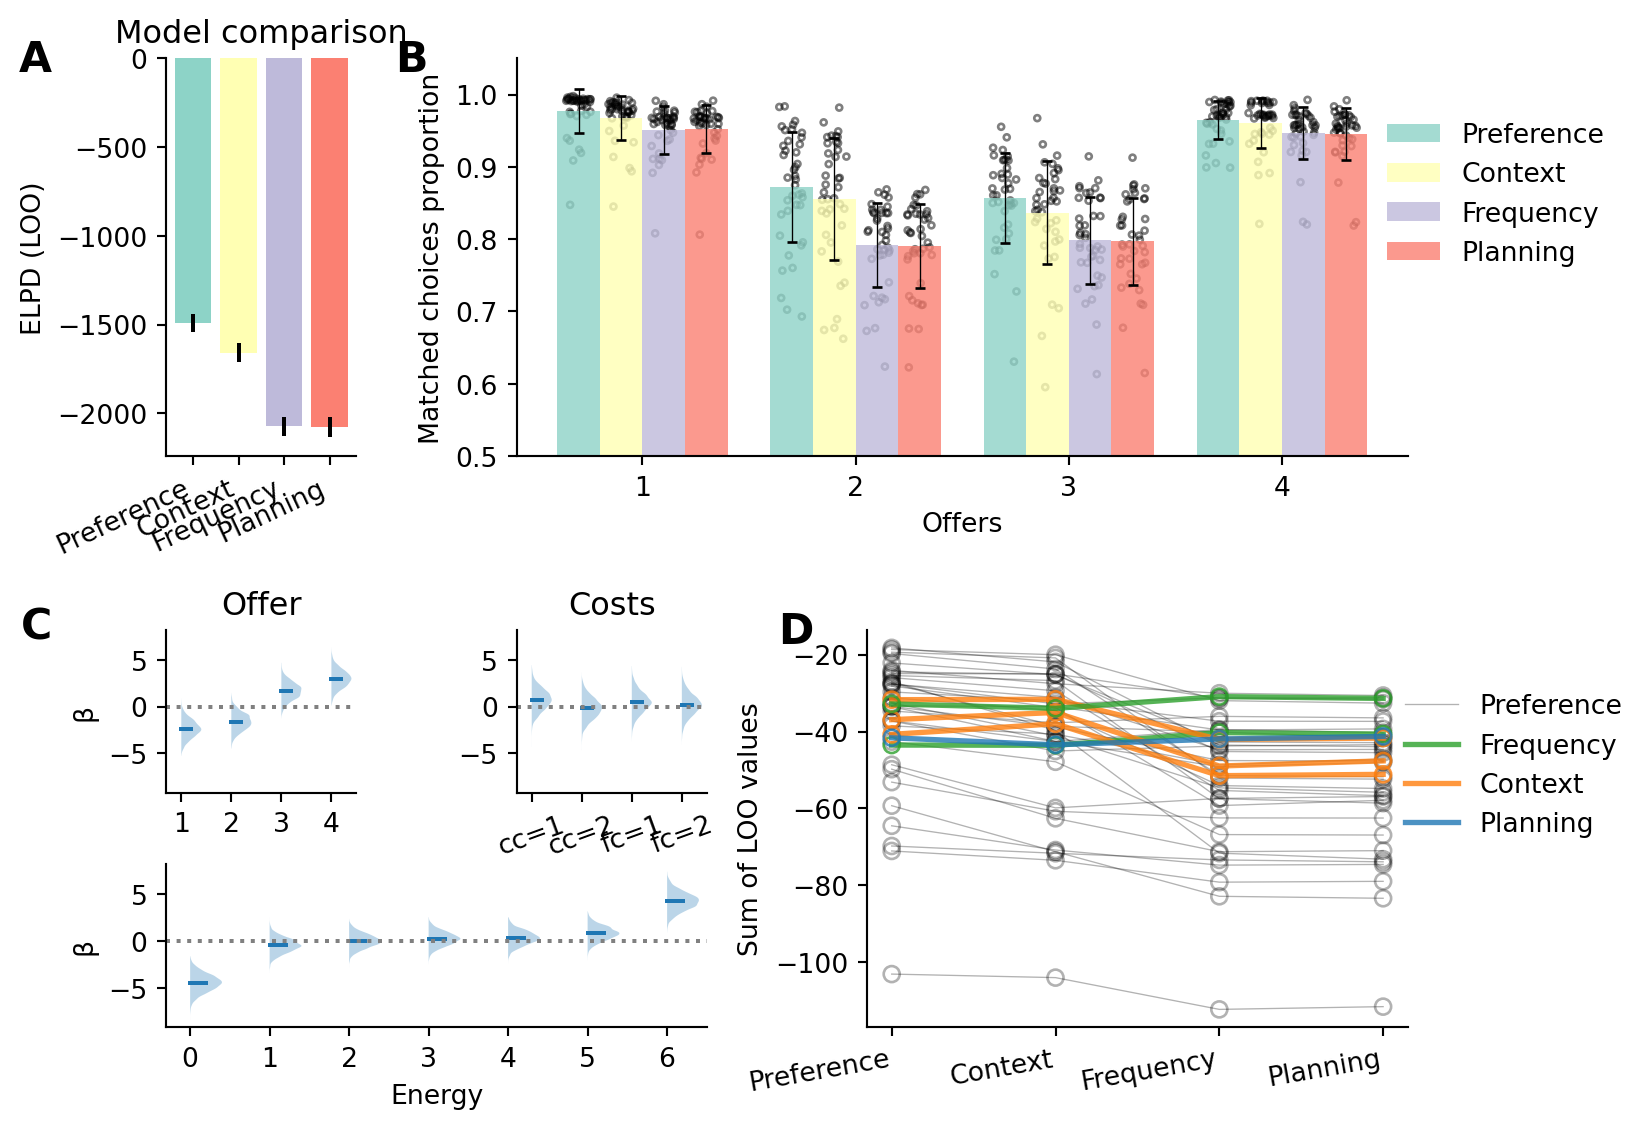

In [11]:
#| label: fig-choicemdl
#| fig-cap: "Results of participants choice behaviour models. (A) Result of the model comparison, displaying the expected log pointwise predictive density (ELPD) 
#| associated with each model (closer to 0 indicate better fit). (B) Observed and fitted probability of accepting the offer separately for each offer by each of the models.
#| The single dots represent the average acceptance probability for each subject. (C) Fitted preference parameters of the preference model. Top left figure 
#| depicts the parameters associated with offer parameters, top right associated with each cost, bottom with each energy level. (D) Model fit for each participant
#| and model, color coded by model of best fit."
fig, ax = plt.subplot_mosaic("ABBB;CCDD", figsize=(9, 6))
# fig, ax = plt.subplots(2, 2, figsize=(12, 12))
cmap = matplotlib.colormaps.get_cmap('Set3')
# ================================================
# fig-2A: model comparison:
# elpd_loo bar plot with error bar
ax["A"].bar(    
    [s.split(' ')[0] for s in model_comparison.index],
    model_comparison["elpd_loo"],
    yerr=model_comparison["se"],
    color=cmap(range(len(model_comparison)))
)
# Decoration
ax["A"].set_ylabel("ELPD (LOO)")
ax["A"].set_title("Model comparison")
ax["A"].set_xticklabels(ax["A"].get_xticklabels(), 
                        rotation=25, ha='right')
ax["A"].spines[['right', 'top']].set_visible(False)
ax["A"].text(-0.6, 1.05, "A", transform=ax["A"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )

# ================================================
# fig-2B: Observed vs. fitted data of each model:
# Plot the true data against predicted values from each model:
pos = [1, 2, 3, 4, 6, 7, 8, 9, 11, 12, 13, 14, 16, 17, 18, 19]
cmap = matplotlib.colormaps.get_cmap('Set3')
ctr = 0
cols = [f"Match_{model_name.lower()}" for model_name in traces.keys()]
lbls = [s.split(' ')[0] for s in traces.keys()]
for o in [1, 2, 3, 4]:
    for col_i, col in enumerate(cols):
        # Group the data per participants:
        val = beh_data[beh_data['reward'] == o].groupby(['vpn'])[col].mean().reset_index()[col].to_numpy() 
        # Plot average across participants
        if o == 1:
            label = lbls[col_i]
        else:
            label = None

        # Plot single participants values:
        ax["B"].scatter(np.random.uniform(0.2, 0.8, len(val)) + pos[ctr]-1/2, val, s=5, marker="o", color='k', facecolors='none', alpha=0.5)
        ax["B"].bar(pos[ctr], np.mean(val), 
                    width=1, 
                    color=cmap(col_i), 
                    label=label,
                    alpha=0.8)
        # Add error bars:
        ax["B"].errorbar(pos[ctr], np.mean(val), yerr=np.std(val), color='k', capsize=2, linewidth=0.5)
        
        ctr += 1
ax["B"].set_xticks([2.5, 7.5, 12.5, 17.5])
ax["B"].set_xticklabels([1, 2, 3, 4])
ax["B"].set_ylim([0.5, 1.05])
ax["B"].set_xlabel("Offers")
ax["B"].set_ylabel("Matched choices proportion")
ax["B"].spines[['right', 'top']].set_visible(False)
ax["B"].text(-0.1, 1.05, "B", transform=ax["B"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
ax["B"].legend(frameon=False, bbox_to_anchor=(0.95, 0.9));

# ================================================
# fig-2C: Plot the preferences parameters of the preference model:
# Split into 4 subplots:
fig.delaxes(ax["C"])

# Create a 2x2 subgrid in its place
subgs = ax["C"].get_subplotspec().subgridspec(2, 2)
ylim = []
# Top row: two separate axes
ax_offer = fig.add_subplot(subgs[0, 0])
ax_costs = fig.add_subplot(subgs[0, 1])
ax_energy = fig.add_subplot(subgs[1, :])

# Create new axes
ax_offer.text(-0.6, 1.15, "C", transform=ax_offer.transAxes, 
                fontsize=16, fontweight='bold', va='top', ha='right'
                ) 

# Plot offer parameters:
data = []
for var in ["B_is_1", "B_is_2", "B_is_3", "B_is_4"]:
    vals = traces['Preference'].posterior["beta_pref"].sel(coef_pref=var).values.flatten()
    data.append(vals)
ax_offer.violinplot(data, positions=range(len(data)), widths=0.8,
                       showmeans=False, showmedians=True,
                       showextrema=False, side="high");
ax_offer.set_xticks(range(len(data)))
ax_offer.set_xticklabels([1, 2, 3, 4])
ax_offer.set_ylabel("β")
ax_offer.hlines(0, -0.3, 3.5, color='gray', linestyles=':')
ax_offer.set_xlim([-0.3, 3.5])
ax_offer.spines[['right', 'top']].set_visible(False)
ax_offer.set_title("Offer")
ylim.append(ax_offer.get_ylim())

# Plot Costs parameters:
data = []
for var in ["B_is_lc", "B_is_hc", "B_is_lfc", "B_is_hfc"]:
    vals = traces['Preference'].posterior["beta_pref"].sel(coef_pref=var).values.flatten()
    data.append(vals)
ax_costs.violinplot(data, positions=range(len(data)), widths=0.8,
                       showmeans=False, showmedians=True,
                       showextrema=False, side="high");
ax_costs.set_xticks(range(len(data)))
ax_costs.set_xticklabels(['cc=1', 'cc=2', 'fc=1', 'fc=2'], rotation=20)
ax_costs.hlines(0, -0.3, 3.5, color='gray', linestyles=':')
ax_costs.set_xlim([-0.3, 3.5])
ax_costs.spines[['right', 'top']].set_visible(False)
ax_costs.set_title("Costs")
ylim.append(ax_costs.get_ylim())

# Plot energy parameters:
data = []
for var in ["B_e_is_0", "B_e_is_1", "B_e_is_2", "B_e_is_3", 
            "B_e_is_4", "B_e_is_5", "B_e_is_6"]:
    vals = traces['Preference'].posterior["beta_pref"].sel(coef_pref=var).values.flatten()
    data.append(vals)
ax_energy.violinplot(data, positions=range(len(data)), widths=0.8, 
                       showmeans=False, showmedians=True,
                       showextrema=False, side="high");
ax_energy.set_xticks(range(len(data)))
ax_energy.set_xticklabels([0, 1, 2, 3, 4, 5, 6])
ax_energy.hlines(0, -0.3, 6.5, color='gray', linestyles=':')
ax_energy.set_xlim([-0.3, 6.5])
ax_energy.set_xlabel('Energy')
ax_energy.spines[['right', 'top']].set_visible(False)
ax_energy.set_ylabel("β")
# ax_energy.set_title("Energy parameters")
ylim.append(ax_energy.get_ylim())

ax_costs.set_ylim([np.min(ylim), np.max(ylim)])
ax_offer.set_ylim([np.min(ylim), np.max(ylim)])
ax_energy.set_ylim([np.min(ylim), np.max(ylim)])

# ================================================
# Single participant model fit:
ctr_mdl = {mdl: 0 for mdl in loo_results.keys()}
cmap = ["k", "tab:orange", "tab:green", "tab:blue"]
for sub in loos_sub['vpn']:
    # Extract the data from this participant:
    sub_loo = loos_sub[loos_sub["vpn"] == sub][loo_results.keys()]
    # Extract the winning model:
    winning = sub_loo.idxmax(axis=1).values[0]
    if ctr_mdl[winning] == 0:
        lbl = winning.split(' ')[0]
    else:
        lbl = None
    # Determine the color accordingly:
    c = cmap[list(loo_results.keys()).index(winning)]
    if winning == "Preference":
        alpha = 0.3
        zorder = 0
        linewidth=0.5
    else:
        alpha = 0.8
        zorder = 1000
        linewidth = 2
    ax["D"].scatter(range(len(traces)), np.squeeze(sub_loo.to_numpy()), color=c, alpha=alpha, facecolors='none', zorder=zorder)
    ax["D"].plot(range(len(traces)), np.squeeze(sub_loo.to_numpy()), color=c, label=lbl, alpha=alpha, zorder=zorder, linewidth=linewidth)
    ctr_mdl[winning] += 1
ax["D"].set_xticks(range(len(traces)))
ax["D"].set_xticklabels([s.split(' ')[0] for s in traces.keys()], rotation=10, ha='right')
ax["D"].set_ylabel("Sum of LOO values")
ax["D"].spines[['right', 'top']].set_visible(False)
ax["D"].legend(frameon=False, bbox_to_anchor=(0.95, 0.9))
ax["D"].text(-0.1, 1.05, "D", transform=ax["D"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
plt.tight_layout();

In [12]:
# Calculate the interaction confidence intervals:
mu_interaction = traces['Preference'].posterior["beta_interaction"].values.flatten().mean()
ci_interaction = az.hdi(traces['Preference'].posterior["beta_interaction"].values)[0]

Our model also revealed a positive interaction between preferences entropy and decision values ($\beta$=`{python} f"{mu_interaction:.2f}"`, CI=[`{python} f"{ci_interaction[0]:.2f}, {ci_interaction[1]:.2f}"`], see @fig-pref-planning-interaction A). This positive interaction entails that the system (i.e. planning vs. preference) with the strongest signal influences participants' choices the most: when participants preferences are strong and decision values are close to 0, participants follow their preferences and vice versa. This effect can be seen when the sign of preferences and DV are opposed (one suggests accepting and the other rejecting or vice versa), as participants choice should either reflect preference or planning depending on their relative strength. To visualize this effect, we plotted participants response as a function of preference and (fitted) decision values with focus on the off diagonal quadrant, where the sign of preferences and decision values are opposed (see @fig-pref-planning-interaction B).

In this figure, we can see that accept and rejected trials cluster in particular ways in the top left and bottom right quadrants. In the top left quadrant, accepting an offer (green triangles) indicate that participants follow their preferences over the DV. There, participants accept offers at increasing decision values as preferences grow larger, while they reject offers (yellow hexagon) at increasing preference values as the decision values grow larger. In contrast, in the bottom right quadrant, accepting an offer implies that participants follow planning. In this quadrant, we can see the opposite relationship: participants reject offers at increasing DV when their preferences grow larger and vice versa for larger DV. These results reflect our interaction term, by showing that participants rely on one signal over the other based on their relative strengths. 

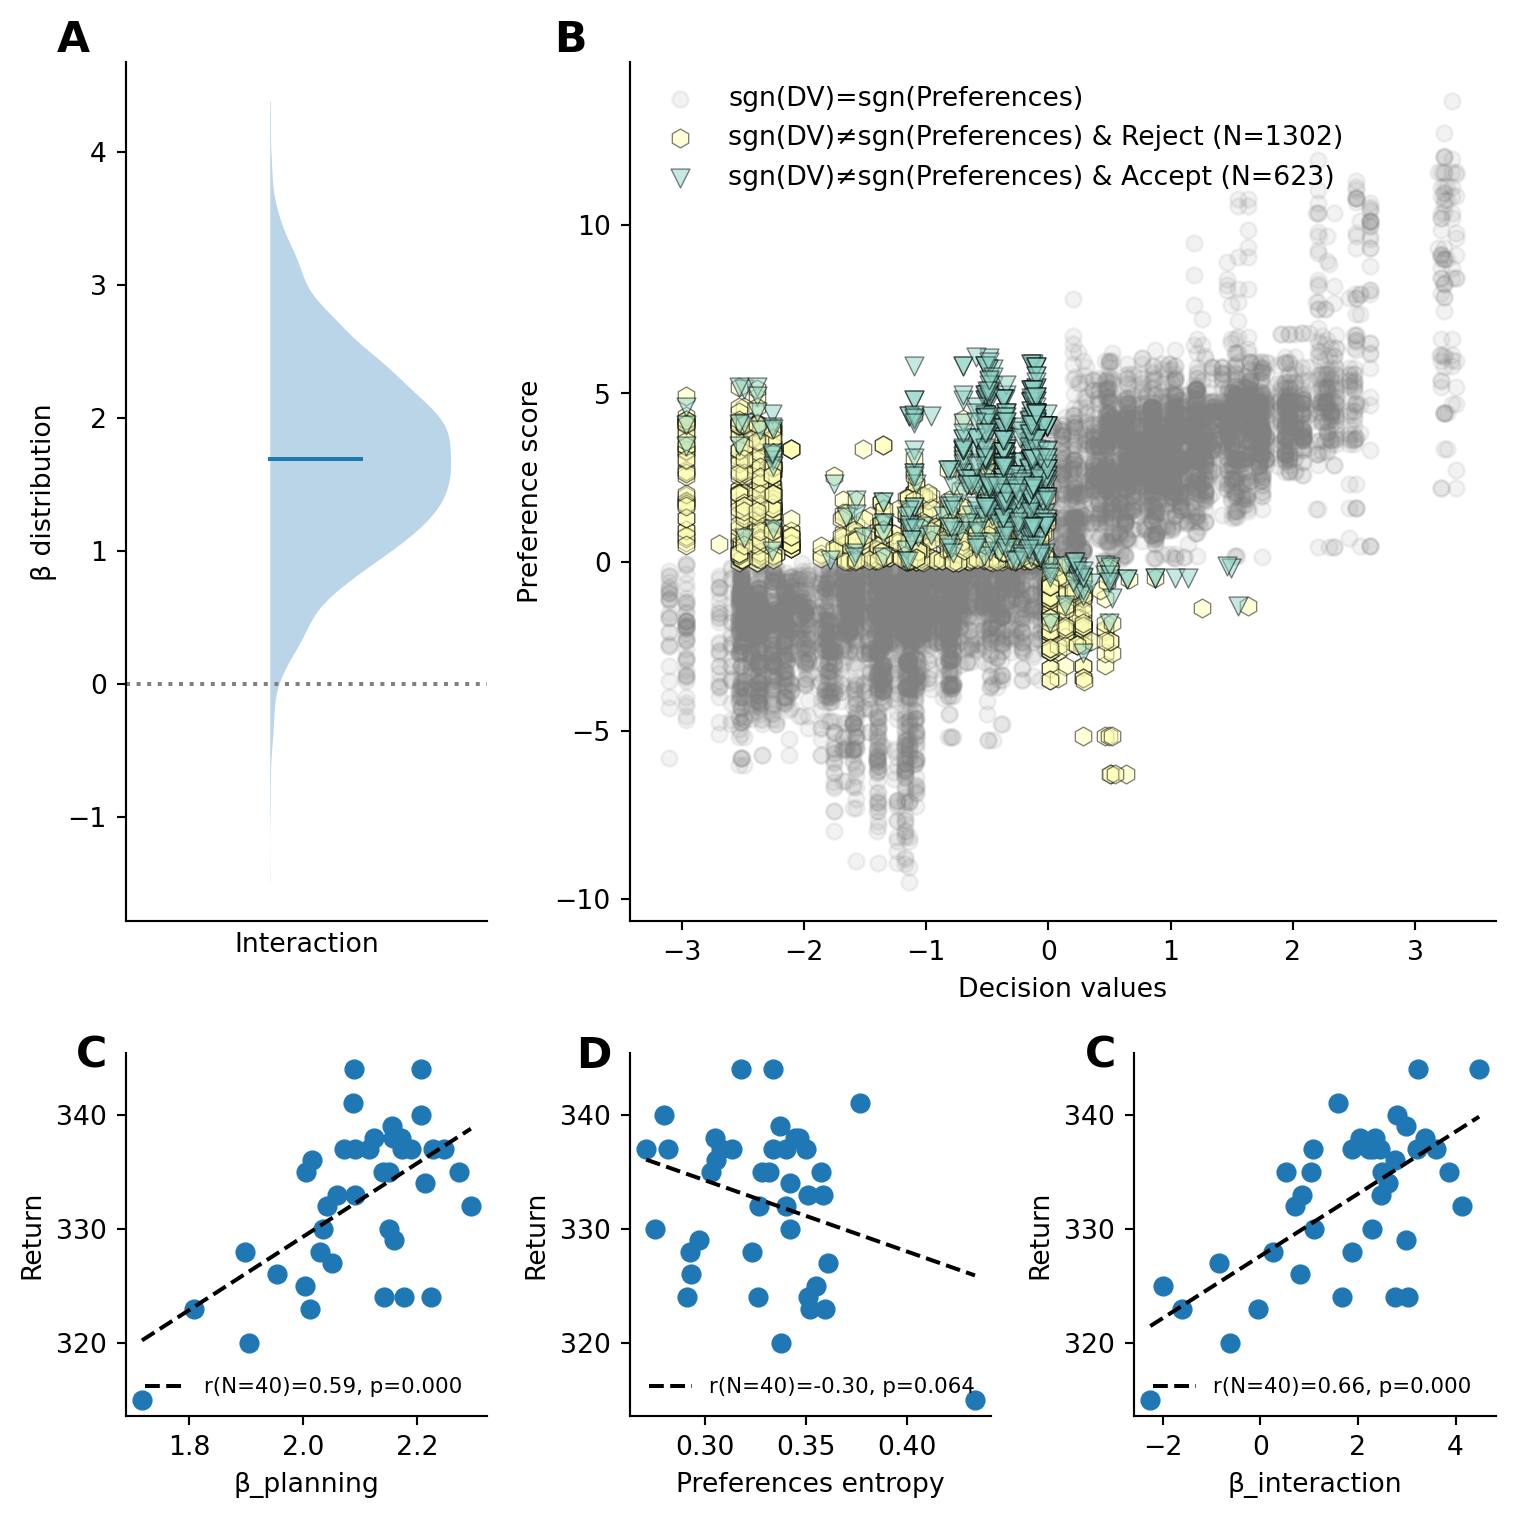

In [13]:
#| label: fig-pref-planning-interaction
#| fig-cap: "Interaction between preferences and decision values. (A) Posterior probability of the interaction parameter of the preference model
#| (B) Shows participants responses as a function of decision values and preference scores. On the off diagonal quadrant (top left and bottom right),
#| the dot color indicate whether participants accepted the reward (green triangles) or rejected the reward (yellow octogons). The number in the legend 
#| indicate hte number of trials of the corresponding colors."
fig, ax = plt.subplot_mosaic("AABBBB;AABBBB;CCDDEE", figsize=(8, 8))

# ================================================================
# fig-3A: Plot the interaction parameter of the preference model:
ax["A"].text(-0.1, 1.05, "A", transform=ax["A"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
# Plot the interaction estimated parameter:
vals = traces['Preference'].posterior["beta_interaction"].values.flatten()

ax["A"].violinplot([vals], positions=[1], 
                    showmeans=False,
                    showmedians=True,
                    showextrema=False,
                    side="high");
ax["A"].set_xticks([])
ax["A"].set_xlabel("Interaction")
ax["A"].spines[['right', 'top']].set_visible(False)
ax["A"].set_ylabel("β distribution")
ax["A"].hlines(0, 0.8, 2.3, color='gray', linestyles=':')
ax["A"].set_xlim([0.8, 1.3])


# ================================================================
# fig-3B: Plot the interaction between preferences and decision values:
cmap = matplotlib.colormaps.get_cmap('Set3')
#beh_data['preference_score'] = np.mean(traces['Preference'].posterior["preference"], axis=(0, 1)).to_numpy()
#beh_data['response_centered'] = beh_data['response'] - 0.5
# Extract the data from a single subject
# # Plot accepted trials:
#accepted_standard = beh_data[(np.sign(beh_data['dv']) == np.sign(beh_data['preference_score'])) & (beh_data["response"] == 1)]
#rejected_standard = beh_data[(np.sign(beh_data['dv']) == np.sign(beh_data['preference_score'])) & (beh_data["response"] == 0)]
#accepted_conflict = beh_data[(np.sign(beh_data['dv']) != np.sign(beh_data['preference_score'])) & (beh_data["response"] == 1)]
#rejected_conflict = beh_data[(np.sign(beh_data['dv']) != np.sign(beh_data['preference_score'])) & (beh_data["response"] == 0)]

#ax["B"].scatter(accepted_standard['dv'], accepted_standard['preference_score'], s=10, 
#                color="k", marker='o', alpha=0.1,
#                 label=f'Accept')
# ax["B"].scatter(rejected_standard['dv'], rejected_standard['preference_score'], s=10,
#                 color="k", marker='x', alpha=0.1,
#                 label=f'Reject')
# ax["B"].scatter(accepted_conflict['dv'], accepted_conflict['preference_score'], s=10, 
#                 color="green", marker='^', alpha=0.3,
#                 label=f'Accept')
# ax["B"].scatter(rejected_conflict['dv'], rejected_conflict['preference_score'], s=10,
#                 color="red", marker='h', alpha=0.3,
#                 label=f'Reject')

# Calcuate the decision boundaries:
# b_plan = np.mean(traces['Preference'].posterior["beta_planning"], axis=(0, 1)).to_numpy()[0]
# b_interaction = np.mean(traces['Preference'].posterior["beta_interaction"], axis=(0, 1)).to_numpy()[0]
# --- Compute Decision Boundary ---
# pref_range = np.linspace(beh_data['preference_score'].min()+3, beh_data['preference_score'].max()-6, 400)
# p = expit(pref_range)
# Avoid log(0) by clipping p
# p = np.clip(p, 1e-10, 1 - 1e-10)
# H = -p * np.log(p) - (1 - p) * np.log(1 - p)
# denominator = b_plan + b_interaction * H
# Avoid division by zero
# denominator[np.abs(denominator) < 1e-10] = np.nan
# dv_boundary = -(pref_range) / denominator
# ax["B"].plot(dv_boundary, pref_range, color='blue', lw=2, label=r'Decision Boundary ($P=0.5$)')


# Add the preferences as an additional column to the data:
beh_data['preference_score'] = np.mean(traces['Preference'].posterior["preference"], axis=(0, 1)).to_numpy()
beh_data['response_centered'] = beh_data['response'] - 0.5
# mismatch 1:
mismatch_accept = beh_data[(np.sign(beh_data['dv']) != np.sign(beh_data['preference_score'])) & (beh_data['response_centered'] > 0)]
# mismatch 2:
mismatch_reject= beh_data[(np.sign(beh_data['dv']) != np.sign(beh_data['preference_score'])) & (beh_data['response_centered'] < 0)]
# Correct responses in the absence of mismatchs:
correct_responses = beh_data[(np.sign(beh_data['dv']) == np.sign(beh_data['preference_score']))]
# Plot each mismatch
ax["B"].scatter(correct_responses['dv'], correct_responses['preference_score'], 
                color="grey", marker='o', alpha=0.1,
                label=f'sgn(DV)=sgn(Preferences)')
ax["B"].scatter(mismatch_reject['dv'], mismatch_reject['preference_score'], 
                color=cmap(1), edgecolors='black', linewidths=0.5, s=50,
                label=f'sgn(DV)≠sgn(Preferences) & Reject (N={mismatch_reject.shape[0]})', marker='h', alpha=0.5)
ax["B"].scatter(mismatch_accept['dv'], mismatch_accept['preference_score'], 
                color=cmap(0), edgecolors='black', linewidths=0.5, s=50,
                label=f'sgn(DV)≠sgn(Preferences) & Accept (N={mismatch_accept.shape[0]})', marker='v', alpha=0.5)

# Decoration:
ax["B"].set_xlabel("Decision values")
ax["B"].set_ylabel("Preference score")
ax["B"].text(-0.05, 1.05, "B", transform=ax["B"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
ax["B"].spines[['right', 'top']].set_visible(False)
ax["B"].legend(frameon=False)

# ================================================================
# fig-3C: Plot the correlation between total return and the planning weight:
# Get the return from each subject:
subjects_returns = []
for sub in beh_data['vpn'].unique():
    subjects_returns.append(beh_data[beh_data['vpn'] == sub]["points"].to_numpy()[-1])
subjects_returns = np.array(subjects_returns)
# Get the corresponding planning beta from the preference model:
planning_betas = np.squeeze(np.mean(traces['Preference'].posterior["beta_planning_sub"], axis=(0, 1)).to_numpy())
# Sort:
sorted_indices = np.argsort(planning_betas)
subjects_returns_sorted = subjects_returns[sorted_indices]
planning_betas_sorted = planning_betas[sorted_indices]
# Compute correlation coefficient:
r = pearsonr(planning_betas_sorted, subjects_returns_sorted)
r_planning, pval_planning = r.statistic, r.pvalue
# Plot correlation between the two:
coef = np.polyfit(np.squeeze(planning_betas_sorted), subjects_returns_sorted, 1)
poly1d_fn = np.poly1d(coef)
ax["C"].scatter(planning_betas_sorted, subjects_returns_sorted,linewidths=0.5, s=50)
ax["C"].plot(planning_betas_sorted, poly1d_fn(planning_betas_sorted), 
             color='k', linestyle='--', label=f'r(N={len(subjects_returns_sorted)})={r.statistic:.2f}, p={r.pvalue:.3f}')
ax["C"].set_xlabel("β_planning")
ax["C"].set_ylabel("Return")
ax["C"].text(-0.05, 1.05, "C", transform=ax["C"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
ax["C"].spines[['right', 'top']].set_visible(False)
ax["C"].legend(frameon=False, prop={'size': 8})

# ================================================================
# fig-3D: Plot the correlation between total return and the preferences entropy:
# Get the return from each subject:
subjects_returns = []
for sub in beh_data['vpn'].unique():
    subjects_returns.append(beh_data[beh_data['vpn'] == sub]["points"].to_numpy()[-1])
subjects_returns = np.array(subjects_returns)
# Get the entropy:
beh_data['entropy'] = np.mean(traces['Preference'].posterior["entropy"], axis=(0, 1))
pref_entropy = beh_data.groupby('vpn')['entropy'].mean().reset_index()['entropy'].to_numpy()
# Sort:
sorted_indices = np.argsort(pref_entropy)
subjects_returns_sorted = subjects_returns[sorted_indices]
pref_entropy_sorted = pref_entropy[sorted_indices]
# Compute correlation coefficient:
r = pearsonr(pref_entropy_sorted, subjects_returns_sorted)
r_pref, pval_pref = r.statistic, r.pvalue
# Plot correlation between the two:
coef = np.polyfit(np.squeeze(pref_entropy_sorted), subjects_returns_sorted, 1)
poly1d_fn = np.poly1d(coef)
ax["D"].scatter(pref_entropy_sorted, subjects_returns_sorted, linewidths=0.5, s=50)
ax["D"].plot(pref_entropy_sorted, poly1d_fn(pref_entropy_sorted), color='k', linestyle='--', 
             label=f'r(N={len(subjects_returns_sorted)})={r.statistic:.2f}, p={r.pvalue:.3f}')
ax["D"].set_xlabel("Preferences entropy")
ax["D"].set_ylabel("Return")
ax["D"].text(-0.05, 1.05, "D", transform=ax["D"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
ax["D"].spines[['right', 'top']].set_visible(False)
ax["D"].legend(frameon=False, prop={'size': 8})

# ================================================================
# fig-3D: Plot the correlation between total return and the preferences entropy:
# Get the return from each subject:
subjects_returns = []
for sub in beh_data['vpn'].unique():
    subjects_returns.append(beh_data[beh_data['vpn'] == sub]["points"].to_numpy()[-1])
subjects_returns = np.array(subjects_returns)
# Get the entropy:
interaction_beta = np.squeeze(np.mean(traces['Preference'].posterior["beta_interaction_sub"], axis=(0, 1)).to_numpy())
# Sort:
sorted_indices = np.argsort(interaction_beta)
subjects_returns_sorted = subjects_returns[sorted_indices]
interaction_beta_sorted = interaction_beta[sorted_indices]
# Compute correlation coefficient:
r = pearsonr(interaction_beta_sorted, subjects_returns_sorted)
r_interaction, pval_interaction = r.statistic, r.pvalue
# Plot correlation between the two:
coef = np.polyfit(np.squeeze(interaction_beta_sorted), subjects_returns_sorted, 1)
poly1d_fn = np.poly1d(coef)
ax["E"].scatter(interaction_beta_sorted, subjects_returns_sorted, linewidths=0.5, s=50)
ax["E"].plot(interaction_beta_sorted, poly1d_fn(interaction_beta_sorted), color='k', linestyle='--', 
             label=f'r(N={len(subjects_returns_sorted)})={r.statistic:.2f}, p={r.pvalue:.3f}')
ax["E"].set_xlabel("β_interaction")
ax["E"].set_ylabel("Return")
ax["E"].text(-0.05, 1.05, "C", transform=ax["E"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )
ax["E"].spines[['right', 'top']].set_visible(False)
ax["E"].legend(frameon=False, prop={'size': 8})
plt.tight_layout();

We would further expected the parameters of our model to be predictive of participants performance. Larger $\beta_{planning}$ values indicate larger reliance on planning on average, which should translate to better performances, as following planning exactly should yield the highest possible return. In contrast, we would expect that participants with stronger priors should obtain lower return, as in contrast to planning, preferences might be wrong (i.e. induce participants to choose an action that does not maximize reward). However, the $\beta_{interaction}$, which encodes the degree of contingency between planning and preferences should also be predictive of performance. Indeed, low $\beta_{interaction}$ would indicate that participants rely on planning regardless of their preferences, which should lead to higher returns. 

Accordingly, we predicted that that $\beta_{planning}$ should be positively correlated with return, while $\beta_{interaction}$ and preferences entropy should be negatively correlated. In line with our prediction, we observed a positive correlation between $\beta_{planning}$ and return (r=`{python} f"{r_planning:.2f}"`, p=`{python} f"{pval_planning:.3f}"`), validating that participants who rely more on planning get larger return (@fig-pref-planning-interaction C). We also observed a negative (though only marginally significant, r=`{python} f"{r_pref:.2f}"`, p=`{python} f"{pval_pref:.3f}"`) between preferences entropy and participants return, indicating that participants with stronger preferences tend to perform less well in the task. However, contradictory to what we had expected, we observed that $\beta_{interaction}$ is strongly positively correlated with return (r=`{python} f"{r_interaction:.2f}"`, p=`{python} f"{pval_interaction:.3f}"`), indicating that participants whose planning is strongly contingent on their preferences perform better in the task. 

### Experimental factors relevance

We observed that both response selection and reaction time reflect value-based combined with preferences and that these preferences themselves reflect the structure of the task. Specifically, our results suggest that participants have preferences related to each factors of the task that then get combined to generate a composite preference score in a given state. Importantly, not  all features of the task are weighted equally. Indeed, we can see in @fig-choicemdl C that the parameters associated with offers and energy weight higher than cost in the preference. To further characterize these differences, we compared models in which the preferences associated with each factor of our task were removed one at a time. 

@fig-5 displays the difference in fit between the full preference model against models in which the preferences related to each experimental factor was removed, larger values indicate that the factor account for a more important proportion of the full model's fit. These results indicate that energy followed by offer have a much larger impact on participants final responses, whereas costs related preferences have a small impact on the overall fit. 

In [14]:
# Full model:
traces_reduced = {"Preference": traces["Preference"]}

if os.path.exists("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_offer_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_offer_trace.nc")
    traces_reduced['Offer'] = idata
else:
    preference_columns = [
        'is_lc', 'is_hc', 
        'is_lfc', 'is_hfc',
        'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6'
    ]
    idata = preference_model(beh_data['response'],  # Subjects responses
                                np.squeeze(beh_data[['dv']].to_numpy()),  # Optimal decision values
                                beh_data[preference_columns],  # Preferences regressors
                                subj_idx_raw, subj_labels)
    # Add the idata to the rest:
    traces_reduced['Offer'] = idata
    # Save the trace to file:
    az.to_netcdf(traces_reduced['Offer'], "./data/bids/limited_energy/derivatives/control_models/preferences_model_no_offer_trace.nc")

# Fit the model without the offer related preferences:
if os.path.exists("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_costs_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_costs_trace.nc")
    traces_reduced['CC'] = idata
else:
    # Fit the model without the costs related preferences:
    preference_columns = [
        'is_1', 'is_2', 'is_3', 'is_4', 
        'is_lfc', 'is_hfc',
        'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6'
    ]
    idata = preference_model(beh_data['response'],  # Subjects responses
                                np.squeeze(beh_data[['dv']].to_numpy()),  # Optimal decision values
                                beh_data[preference_columns],  # Preferences regressors
                                subj_idx_raw, subj_labels)
    # Add the idata to the rest:
    traces_reduced['CC'] = idata
    # Save the trace to file:
    az.to_netcdf(traces_reduced['CC'], "./data/bids/limited_energy/derivatives/control_models/preferences_model_no_costs_trace.nc")

# Fit the model without the offer related preferences:
if os.path.exists("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_fc_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_fc_trace.nc")
    traces_reduced['FC'] = idata
else:
    # Fit the model without the transitions related preferences:
    preference_columns = [
        'is_1', 'is_2', 'is_3', 'is_4', 
        'is_lc', 'is_hc', 
        'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6'
    ]
    idata = preference_model(beh_data['response'],  # Subjects responses
                                np.squeeze(beh_data[['dv']].to_numpy()),  # Optimal decision values
                                beh_data[preference_columns],  # Preferences regressors
                                subj_idx_raw, subj_labels)
    # Add the idata to the rest:
    traces_reduced['FC'] = idata
    # Save the trace to file:
    az.to_netcdf(traces_reduced['FC'], "./data/bids/limited_energy/derivatives/control_models/preferences_model_no_fc_trace.nc")

# Fit the model without the offer related preferences:
if os.path.exists("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_energy_trace.nc"):
    idata = az.from_netcdf("./data/bids/limited_energy/derivatives/control_models/preferences_model_no_energy_trace.nc")
    traces_reduced['Energy'] = idata
else:
    # Fit the model without the energy related preferences:
    preference_columns = [
        'is_1', 'is_2', 'is_3', 'is_4', 
        'is_lc', 'is_hc', 
        'is_lfc', 'is_hfc',
    ]
    idata = preference_model(beh_data['response'],  # Subjects responses
                                np.squeeze(beh_data[['dv']].to_numpy()),  # Optimal decision values
                                beh_data[preference_columns],  # Preferences regressors
                                subj_idx_raw, subj_labels)
    # Add the idata to the rest:
    traces_reduced['Energy'] = idata
    # Save the trace to file:
    az.to_netcdf(traces_reduced['Energy'], "./data/bids/limited_energy/derivatives/models/preferences_model_no_energy_trace.nc")

# Compare against the full model:
model_comparison = az.compare(traces_reduced)

In [15]:
# Compute the reduced MDPs:
return_reduced = {
    "Offer": None,
    "Energy": None,
    "CC": None,
    "FC": None,
}
max_return = task_mdp.expected_return(task_mdp.soft_policy(Q_full), initial_energy=3)

# ==================================================================
# Offer reduced MDP:
# Get all single states without the offers:
inds = [0, 2, 3, 4]
states_no_offers = list(set(tuple([state[i] for i in inds]) for state in task_mdp.states))
# Create state classes, i.e. list of states groups that share everything but the offer:
states_classes = []
for state_r in states_no_offers:
    class_ = []
    for state in task_mdp.states:
        if tuple(state[i] for i in inds) == state_r:
            class_.append(state)
    states_classes.append(class_)
# Reduce the MDP accordingly:
statesR, tpR, rR, class_of_state = avg_reduce_mdp(states_classes, task_mdp.tp, task_mdp.r, task_mdp.s2i)
# Create abstract MDP:
V_R, Q_R = MDP(statesR, tpR, rR, gamma).backward_induction()
# Project back to ground space:
_, Q = abstract2ground_value(class_of_state, V_R, Q_R)
# Compute the expected return:
return_reduced["Offer"] = task_mdp.expected_return(task_mdp.soft_policy(Q), initial_energy=3) / max_return

# ==================================================================
# Energy reduced MDP:
# Get all single states without the Energy:
inds = [1, 2, 3, 4]
states_no_energy =  list(set(tuple([state[i] for i in inds]) for state in task_mdp.states))
# Create state classes, i.e. list of states groups that share everything but the offer:
states_classes = []
for state_r in states_no_energy:
    class_ = []
    for state in task_mdp.states:
        if tuple(state[i] for i in inds) == state_r:
            class_.append(state)
    states_classes.append(class_)
# Reduce the MDP accordingly:
statesR, tpR, rR, class_of_state = avg_reduce_mdp(states_classes, task_mdp.tp, task_mdp.r, task_mdp.s2i)
# Create abstract MDP:
V_R, Q_R = MDP(statesR, tpR, rR, gamma).backward_induction()
# Project back to ground space:
_, Q = abstract2ground_value(class_of_state, V_R, Q_R)
# Compute the expected return:
return_reduced["Energy"] = task_mdp.expected_return(task_mdp.soft_policy(Q), initial_energy=3) / max_return

# ==================================================================
# CC reduced MDP:
# Get all single states without the offers:
inds = [0, 1, 3, 4]
states_no_cc=  list(set(tuple([state[i] for i in inds]) for state in task_mdp.states))
# Create state classes, i.e. list of states groups that share everything but the offer:
states_classes = []
for state_r in states_no_cc:
    class_ = []
    for state in task_mdp.states:
        if tuple(state[i] for i in inds) == state_r:
            class_.append(state)
    states_classes.append(class_)
# Reduce the MDP accordingly:
statesR, tpR, rR, class_of_state = avg_reduce_mdp(states_classes, task_mdp.tp, task_mdp.r, task_mdp.s2i)
# Create abstract MDP:
V_R, Q_R = MDP(statesR, tpR, rR, gamma).backward_induction()
# Project back to ground space:
_, Q = abstract2ground_value(class_of_state, V_R, Q_R)
# Compute the expected return:O
return_reduced["CC"] = task_mdp.expected_return(task_mdp.soft_policy(Q), initial_energy=3) / max_return

# ==================================================================
# FC reduced MDP:
# Get all single states without the offers:
inds = [0, 1, 2, 4]
states_no_fc =  list(set(tuple([state[i] for i in inds]) for state in task_mdp.states))
# Create state classes, i.e. list of states groups that share everything but the offer:
states_classes = []
for state_r in states_no_fc:
    class_ = []
    for state in task_mdp.states:
        if tuple(state[i] for i in inds) == state_r:
            class_.append(state)
    states_classes.append(class_)
# Reduce the MDP accordingly:
statesR, tpR, rR, class_of_state = avg_reduce_mdp(states_classes, task_mdp.tp, task_mdp.r, task_mdp.s2i)
# Create abstract MDP:
V_R, Q_R = MDP(statesR, tpR, rR, gamma).backward_induction()
# Project back to ground space:
_, Q = abstract2ground_value(class_of_state, V_R, Q_R)
# Compute the expected return:
return_reduced["FC"] = task_mdp.expected_return(task_mdp.soft_policy(Q), initial_energy=3) / max_return

# Sort the dictionary:
return_reduced = {k: v for k, v in sorted(return_reduced.items(), reverse=True, key=lambda item: item[1])}

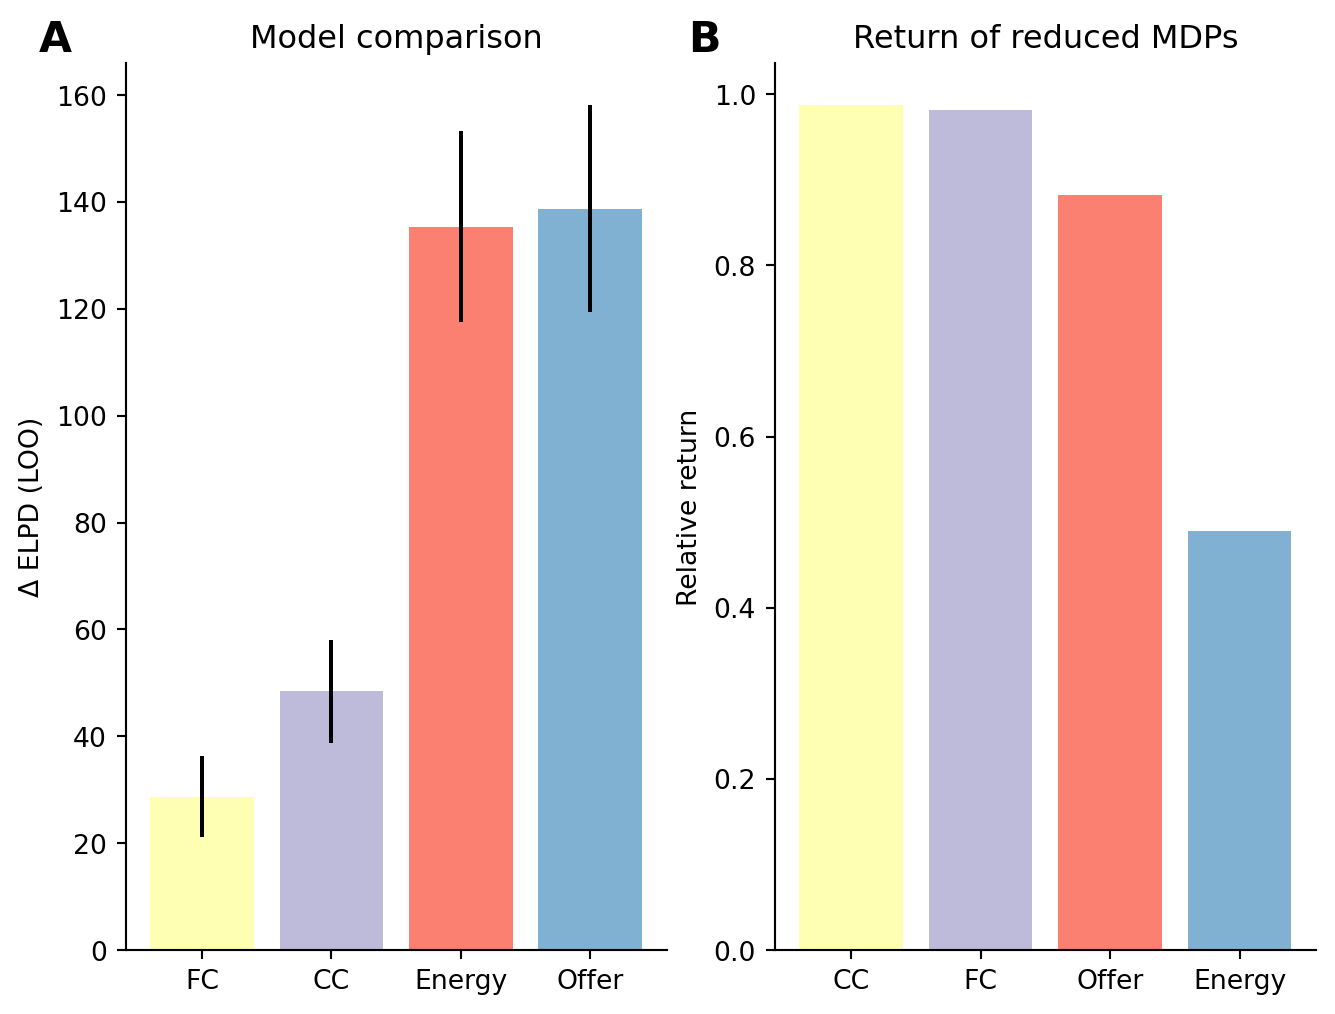

In [16]:
#| label: fig-5
#| fig-cap: "Importance of each parameters in participants response and optimal solution. (A) Difference in fit
#| between the full preference model and models in which each of the experimental factors were removed from preference estimations. 
#| Values closer to 0 indicate that the factor does not lead to a strong improvement of the model fit (i.e. the factor weight less in
#| participants final decision). (B) Relative expected return of reduced MDPs in which each of the factors were removed. Values closer 
#| to 1 indicate that the factor does not lead to a strong decrease in the expected return (i.e. the factor weight less in the 
#| optimal solution). The strong impact of energy on return is to be expected, as participants treating all energy levels the same (i.e. only one 
#| average energy level) would accept offers more often than they should, quickly running out of energy and not be able to obtain rewards in the future. 
#| Similarly, participants who ignore offer would not preferentially accept large offer and therefore sacrifice energy when it would be best to keep 
#| it to accept future rewards. " 
fig, ax = plt.subplot_mosaic("AB", figsize=(8, 6))  # , gridspec_kw=dict(width_ratios=[0.5, 1]))
# fig, ax = plt.subplots(2, 2, figsize=(12, 12))
cmap = matplotlib.colormaps.get_cmap('Set3')
# ================================================
# fig-2A: model comparison:
# elpd_loo bar plot with error bar
ax["A"].bar(    
    range(len(model_comparison)-1),
    model_comparison.iloc[1:]["elpd_diff"],
    yerr=model_comparison.iloc[1:]["dse"],
    color=cmap([1, 2, 3, 4])
)
# Decoration
ax["A"].set_xticks(range(len(model_comparison)-1))
ax["A"].set_xticklabels(model_comparison.index[1:])
ax["A"].set_ylabel("Δ ELPD (LOO)")
ax["A"].set_title("Model comparison")
ax["A"].spines[['right', 'top']].set_visible(False)
ax["A"].text(-0.1, 1.05, "A", transform=ax["A"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              );

ax["B"].bar(    
    return_reduced.keys(),
    list(return_reduced.values()),
    color=cmap([1, 2, 3, 4])
)
# Decoration
ax["B"].set_xticks(range(len(return_reduced)))
ax["B"].set_xticklabels(return_reduced.keys())
ax["B"].set_ylabel("Relative return")
ax["B"].set_title("Return of reduced MDPs")
ax["B"].spines[['right', 'top']].set_visible(False)
ax["B"].text(-0.1, 1.05, "B", transform=ax["B"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              );

This differential weighting of experimental factors might reflect a general bias towards certain features (such as reward and energy) over others, due to their overall relevance in the environment. Alternatively, these may reflect that based on the structure of our task, certain features might be more relevant than others to maximize rewards, such that when ignoring more relevant dimensions of the task when planning leads to larger reward loss than others. If that is the case, an agent with limited processing capabilities should attend to this features more [@ho2022people], which might be what the differential weighting of participants' preferences reflect. 

To provide supporting evidence for the latter claim, we computed the expected return from simplified representations of the task in which each experimental factor is omitted one at a time, to quantify the loss in reward associated with ignoring it. The results are shown in @fig-5 B. We observe that order of the factors in terms of their relevance for returns is reminescent of participants's weighting of those factors in their preferences. Indeed, both current and future costs have relatively low impact on the overall return, while offer and more critically energy have a larger impact, which reflects preferences weighting. While this does not constitute definitive evidence, these results suggests that participants preferences might not only reflect bias based on previous experience in their environment, but might also be adapted to the structure of the task. 

### Reaction times
As the extent to which participants engage in planning should be refected in participants RT, we predicted that participants RT should reflect the difference in long term value (i.e. conflict) associated with each action (as planning is facilitated when the value of accept and reject are clearly distinct), preferences associated with each state (as stronger preferences should be associated with less planning) and the interaction between the two (as the planning facilitations associated conflict should be expressed more when participants preferences are weak). 

In line with our prediction, we observed that participants RT was best captured by considering the difference in value between actions, the strength of participants preferences and the interaction between the two (see @fig-rt A). The positive interaction (see @fig-rt B) between conflict and preferences indicate that the dependence of planning on the degree of conflict is further modulated by the strength of participants' preferences. As can be seen in @fig-rt C, planning depends little on conflict when preferences are strong (entropy close to 0), but increasingly when preferences grow weaker (preference entropy of 0.5 or 1.0). Combined with the choice model, these results indicate that participants engage in forward planning only to reduce the current uncertainty in their choice if their prior are not precise enough.

In [17]:
#| include: false
beh_data['logRT'] = np.log(beh_data['reaction_time'])

# Repeat Ott's RT model:
beh_data['conflict'] = -np.abs(beh_data['dv'])
beh_data['intermediate'] = beh_data['is_2'] + beh_data['is_3']
beh_data['entropy'] = np.mean(traces['Preference'].posterior["entropy"], axis=(0, 1))

traces_RT = {}

# ===================================================================
# Conflict entropy interaction model:
interaction_rt_model = bmb.Model(
    "logRT ~ conflict + entropy + conflict:entropy +"
    "(conflict + entropy|vpn)", 
    beh_data
    )
traces_RT['RT=ConflictxH(Pref)'] = interaction_rt_model.fit(
    draws=1000, target_accept=0.95, idata_kwargs={"log_likelihood": True},
)

# ===================================================================
# Conflict entropy model without interaction:
pref_conflict_rt_model = bmb.Model(
    "logRT ~ conflict + entropy +"
    "(conflict + entropy|vpn)", 
    beh_data
    )
traces_RT['RT=Conflict+H(Pref)'] = pref_conflict_rt_model.fit(
    draws=1000, target_accept=0.95, idata_kwargs={"log_likelihood": True},
)

# ===================================================================
# Conflict entropy interaction model:
conflict_rt_model = bmb.Model(
    "logRT ~ conflict +"
    "(conflict|vpn)", 
    beh_data
    )
traces_RT['RT=Conflict'] = conflict_rt_model.fit(
    draws=1000, target_accept=0.95, idata_kwargs={"log_likelihood": True},
)

# Compare the models:
rt_model_comparison = az.compare(traces_RT)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, conflict, entropy, conflict:entropy, 1|vpn_sigma, 1|vpn_offset, conflict|vpn_sigma, conflict|vpn_offset, entropy|vpn_sigma, entropy|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 51 seconds.


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, conflict, 1|vpn_sigma, 1|vpn_offset, conflict|vpn_sigma, conflict|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 38 seconds.


In [154]:
rt_model_comparison

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
RT=ConflictxH(Pref),0,-6002.370570,141.997841,0.000000,0.898353,411.825935,0.000000,True,log
RT=Conflict+H(Pref),1,-6011.821040,137.339897,9.450470,0.016595,410.374522,4.849851,True,log
RT=Conflict,2,-6188.540859,109.216291,186.170288,0.085052,400.563821,25.617062,True,log


Default computed for unspecified variable: vpn


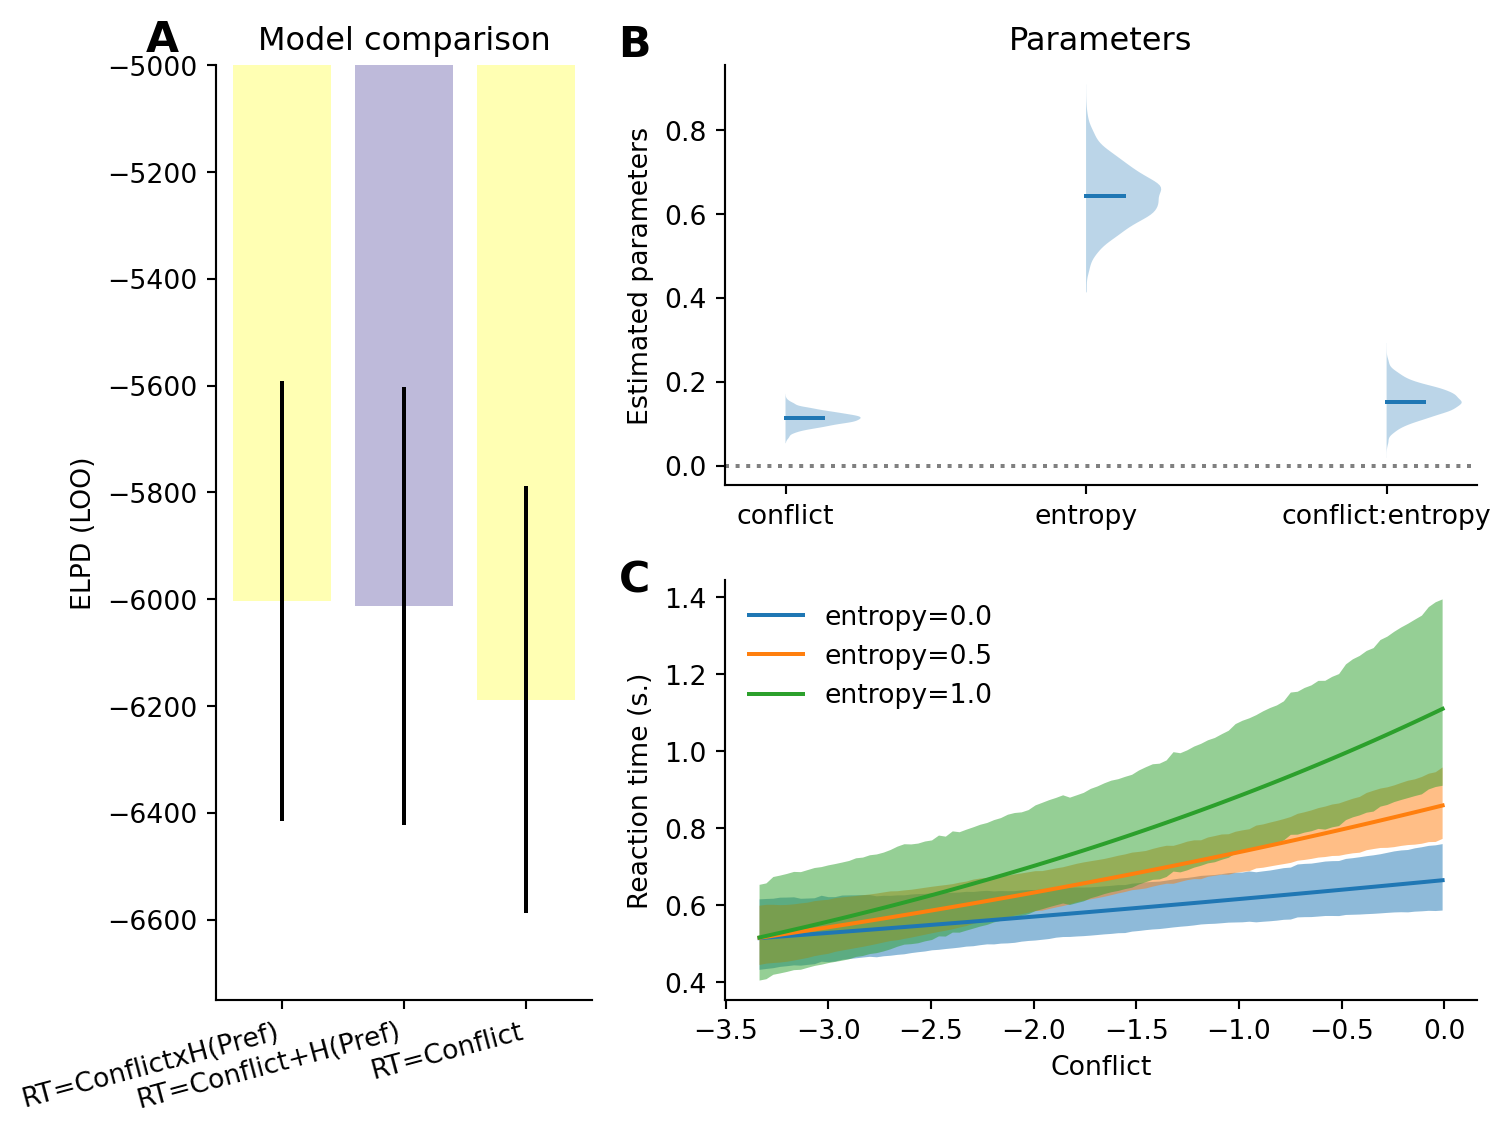

In [18]:
#| label: fig-rt
#| fig-cap: "Results of reaction time models. (A) Comparison of the model of RT as a function of decision values and intermediate offer against the model of RT
#| as a function of decision values and preferences. (B) Posterior distribution of the fitted parameter. (C) Posterior predictive curve depicting the predicted
#| reaction time as a function of the conflict values, separately for preference entropy of 0, 0.5 and 1.0"
fig, ax = plt.subplot_mosaic("AB;AC", figsize=(8, 6), gridspec_kw=dict(width_ratios=[0.5, 1]))
# ================================================
# fig-2A: model comparison:
# elpd_loo bar plot with error bar
ax["A"].bar(    
    list(traces_RT.keys()),
    rt_model_comparison["elpd_loo"],
    yerr=rt_model_comparison["se"],
    color=cmap([1, 2])
)
# Decoration
ax["A"].set_xticklabels(ax["A"].get_xticklabels(), 
                        rotation=15, ha='right')
ax["A"].set_ylabel("ELPD (LOO)")
ax["A"].set_ylim([-6750, -5000])
ax["A"].set_title("Model comparison")
ax["A"].spines[['right', 'top']].set_visible(False)
ax["A"].text(-0.1, 1.05, "A", transform=ax["A"].transAxes, 
              fontsize=16, fontweight='bold', va='top', ha='right'
              )

# ================================================
# fig-B: Plot the preferences parameters of the preference & conflict model:
# Create new axes
params = [
    "conflict", "entropy", "conflict:entropy"
]
x_labels = ["conflict", "entropy", "conflict:entropy"]

ax["B"].set_ylabel("Estimated parameters")
data = []
for var in params:
    vals = traces_RT['RT=ConflictxH(Pref)'].posterior[var].values.flatten()
    data.append(vals)
ax["B"].violinplot(data, positions=range(len(params)), 
                    showmeans=False,
                    showmedians=True,
                    showextrema=False,
                    side="high");
ax["B"].set_xticks(range(len(params)))
ax["B"].set_xticklabels(x_labels)
ax["B"].spines[['right', 'top']].set_visible(False)
ax["B"].set_title("Parameters")
ax["B"].hlines(0, -0.2, 2.3, color='gray', linestyles=':')
ax["B"].set_xlim([-0.2, 2.3])
ax["B"].text(-0.1, 1.1, "B", transform=ax["B"].transAxes, 
                fontsize=16, fontweight='bold', va='top', ha='right'
                ) 

# ================================================
# fig-C: Plot the preferences parameters of the preference & conflict model:
pred_df = bmb.interpret.predictions(
    interaction_rt_model,
    traces_RT['RT=ConflictxH(Pref)'],
    conditional={
        "conflict": np.linspace(beh_data['conflict'].min(), beh_data['conflict'].max(), 100),
        "entropy": [0, 0.5, 1]
    },
)
pred_df["RT"] = np.exp(pred_df["estimate"])
pred_df["RT_low"] = np.exp(pred_df["lower_3.0%"])
pred_df["RT_up"] = np.exp(pred_df["upper_97.0%"])

for ent in pred_df["entropy"].unique():
    subset = pred_df[pred_df["entropy"] == ent]
    ax["C"].plot(subset["conflict"], subset["RT"], label=f"entropy={ent}")
    ax["C"].fill_between(subset["conflict"], subset["RT_low"], subset["RT_up"], alpha=0.5)
ax["C"].spines[['right', 'top']].set_visible(False)
ax["C"].set_xlabel('Conflict')
ax["C"].set_ylabel('Reaction time (s.)')
ax["C"].legend(frameon=False)
ax["C"].text(-0.1, 1.05, "C", transform=ax["C"].transAxes, 
                fontsize=16, fontweight='bold', va='top', ha='right'
                ) 
plt.tight_layout();

## Discussion
- High level summary of results interpretation
- Discuss how the results relate to the notion of computational rationality and policy compression
In policy compression framework, planning is complemented by the marginal action probability which is taken to constitute a prior over action. Our use of preferences constitutes an extension to it. Instead of considering marginal probability across states, our preferences define action probability based on the structure of the task, informing the default policy of subjects beyond what is done in traditional policy compression. Or put differently, in policy compression, assuming that participants are under too much pressure to rely on planning, participants should rely on state independent action prior, which is very restrictive and probably not adaptive. It is likely that participants rely on more information to make adaptive decisions even when planning is limited. Our Preferences offer a solution to this
- Discuss how the results relate to Sarah's model (2024 PLoS CB paper) and the idea of Certainty-based stopping criterion
- Discuss how the results relate to the traditional distinction between habits and goal directed. Preferences might reflect the habit process, and our results might indicate that both modules are at play, just that planning kicks in only if habits are weak, also in line with Sarah's work on balancing habits and goal directed behaviour paper from 2021

- A limitation of the present work is we assume that preferences are fixed, thought they are likely to be dynamically updated throughout the task. Future work should aim to characterize preferences update mechanisms, by dynamically updating both the reward and transitional probabilty structure of the task, either in a gradually or chunk-wise (i.e. having separate experimental blocks with different task structures).

## Acknowledgements

## Data and code statement
All data used in this paper were previously published as part of @ott2022forward, and are available at https://zenodo.org/records/6328296. Code can be found on github https://github.com/AlexLepauvre/state_abstraction_paper. In addition, we've created a custom toolbox to implement reinforcement learning algorithm, which can be found here: https://github.com/AlexLepauvre/state-abstraction

## References

:::{#refs}

:::